# Dusty Red Galaxies in COSMOS-Web
AP 2026

Fitting ALMA spectra and SED fitting


In [20]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy
from utilities.cosmosWebHandler import CosmosWebHandler
from utilities.jadesHandler import JadesHandler
from utilities.catalogHandler import CatalogHandler

from astropy.table import Table
from astropy.io import fits
from utilities.almaA3Handler import AlmaA3Handler
from utilities.champsHandler import ChampsHandler
from utilities.mighteeHandler import MighteeHandler
from utilities.superDeblendedHandler import SuperDeblendedHandler
from utilities.jadesApertureEnum import JadesApertureEnum
from utilities.cosmosWebApertureEnum import CosmosWebApertureEnum
from utilities.bandEnum import BandEnum
from utilities.almaSpectraHandler import AlmaSpectraHandler

from astropy.wcs import WCS
from astropy.io import fits
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u
import fitz  # PyMuPDF
import os
from IPython.display import HTML
import pandas as pd

In [3]:
# constants
# CATALOG_PATH = "/Volumes/Apple SDXC Reader Media/dusty-red/data/COSMOSWeb_mastercatalog_v1.1.fits"
# CATALOG_LIGHT_PATH = '/Volumes/Apple SDXC Reader Media/dusty-red/data/COSMOSWeb_mastercatalog_v1.1_no_cigale_no_bd_no_ml_morpho_no_se_aper_no_galfitm_morpho.fits'  # a lighter version of the catalog with the cigale, bd, ml-morpho, se_aper, and galfitm-morpho columns removed to save space and load time, since we won't be using those columns in our analysis
CATALOG_LIGHTER_PATH = '/Volumes/Apple SDXC Reader Media/dusty-red/data/COSMOSWeb_mastercatalog_v1.1_no_cigale_no_bd_no_ml_morpho_no_se_aper_no_galfitm_morpho_lightphotom.fits'  # an even lighter version of the catalog with only the photometric columns (and the id, ra, dec columns) included, for quick loading when we only need the photometric data and not the lephare/cigale/bd/ml-morpho/se_aper/galfitm-morpho data
# CATALOG_LIGHTEST_PATH = '/Volumes/Apple SDXC Reader Media/dusty-red/data/COSMOSWeb_mastercatalog_v1.1_no_cigale_no_bd_no_ml_morpho_no_se_aper_no_galfitm_morpho_lightphotom_condition_clean_miri.fits'  # an even lighter version of the catalog with only the photometric columns (and the id, ra, dec columns) included, and only the objects that pass the condition_clean_miri cut included, for quick loading when we only need the photometric data for the objects that pass the condition_clean_miri cut.

DATA_DIR    = '/Volumes/Apple SDXC Reader Media/dusty-red/data'   # folder with the tiles
# (old) only needed if viewing the tile images of the catalog objects

CHAMPS_PRELIM_PRIOR_CATALOG = '/Volumes/Apple SDXC Reader Media/dusty-red/data/alma_prelim_catalog/Catalogs/champs_prior_catalog.fits'
CHAMPS_PRELIM_BLIND_CATALOG = '/Volumes/Apple SDXC Reader Media/dusty-red/data/alma_prelim_catalog/Catalogs/champs_blind_catalog.fits'
CHAMPS_IMAGE_MAP40 = '/Volumes/Apple SDXC Reader Media/dusty-red/data/alma_prelim_catalog/image_maps/champs_full_field_concat_split_pbcorr_40.fits'
CHAMPS_IMAGE_MAP20 = '/Volumes/Apple SDXC Reader Media/dusty-red/data/alma_prelim_catalog/image_maps/champs_full_field_concat_split_pbcorr_20.fits'
CHAMPS_IMAGE_MAP = '/Volumes/Apple SDXC Reader Media/dusty-red/data/alma_prelim_catalog/image_maps/champs_full_field_concat_split_image.fits'

MIGHTEE_CATALOG = '/Volumes/Apple SDXC Reader Media/dusty-red/data/mightee_continuum/MIGHTEE_Continuum_DR1_COSMOS_5p2arcsec_I_v1.1.fits'
L_BAND_IMAGE = '/Volumes/Apple SDXC Reader Media/dusty-red/data/mightee_continuum/COSMOS_XS_VLA_Lband.fits'
S_BAND_IMAGE = '/Volumes/Apple SDXC Reader Media/dusty-red/data/mightee_continuum/COSMOS_XS_VLA_Sband_img.fits'
VLA_3GHZ_IMAGE = '/Volumes/Apple SDXC Reader Media/dusty-red/data/mightee_continuum/vla_3ghz_msmf.fits'

SUPER_DEBLENDED_CATALOG = '/Volumes/Apple SDXC Reader Media/dusty-red/data/super-deblended/COSMOS_deblended_FIR_201821_photo_phys_2023June.fits'

S2COSP0762_ALMA_SPECTRA = '/Volumes/Sandisk/dusty-red/alma-spectra/171478/S2COS0762_ALMA_stacked_spectra.txt'
S2COSP0762_ALMA_CLEAN = '/Volumes/Sandisk/dusty-red/alma-spectra/171478/S2COS0762-CO54-clean.fits'

ALMA_A3_PRIOR_CATALOG = '/Volumes/Apple SDXC Reader Media/dusty-red/data/almaA3Cosmos/catalogues v20250312/A-COSMOS_prior_v20250312_Gaussian_with_meta_corrected_within_Pbcor_0.1_to_publish.fits'
ALMA_A3_BLIND_CATALOG = '/Volumes/Apple SDXC Reader Media/dusty-red/data/almaA3Cosmos/catalogues v20250312/A-COSMOS_blind_v20250312_PyBDSF_with_meta_corrected_within_Pbcor_0.1_with_combined_surveys_to_publish.fits'

# cosmos-web catalog

In [4]:
# load the handler
catalogHandler = CosmosWebHandler(CATALOG_LIGHTER_PATH)

catalogHandler.load_catalog(CATALOG_LIGHTER_PATH)


Filename: /Volumes/Apple SDXC Reader Media/dusty-red/data/COSMOSWeb_mastercatalog_v1.1_no_cigale_no_bd_no_ml_morpho_no_se_aper_no_galfitm_morpho_lightphotom.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  PHOTOMETRY    1 BinTableHDU     85   784016R x 38C   [K, D, D, D, D, D, D, K, D, D, 5D, D, 5D, 5D, D, D, 5D, D, 5D, 5D, D, D, 5D, D, 5D, 5D, D, D, 5D, D, 5D, 5D, D, D, 5D, D, 5D, 5D]   
  2  LEPHARE       1 BinTableHDU     13   784016R x 2C   [K, D]   
 HDU Info: None
Catalog loaded successfully. Tables present: photom, lephare
Purity cut: 650707 out of 784016 objects remain. Fraction: 83.00%
MIRI cut: 177816 out of 650707 objects remain. Fraction: 27.33%


In [5]:
#read the cosmos web header
print("Reading the COSMOSWeb header...")
print(catalogHandler.hdr)

Reading the COSMOSWeb header...
XTENSION= 'BINTABLE'           / binary table extension                         BITPIX  =                    8 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                  784 / length of dimension 1                          NAXIS2  =               784016 / length of dimension 2                          PCOUNT  =                    0 / number of group parameters                     GCOUNT  =                    1 / number of groups                               TFIELDS =                   38 / number of table fields                         TTYPE1  = 'id      '                                                            TFORM1  = 'K       '                                                            TTYPE2  = 'ra      '                                                            TFORM2  = 'D       '                                                            TTYPE3  

## make detection cuts

#### condition detection -- flux aperature

In [6]:
aperature_for_analysis = CosmosWebApertureEnum.APER_0p5.value if isinstance(catalogHandler, CosmosWebHandler) else None

if aperature_for_analysis is None:
    raise NotImplementedError("Aperture for analysis not defined for this catalog handler type.")

print(f"Using aperture {aperature_for_analysis} for analysis.")

# catalogHandler.clean_miri_cut(aperature = JadesApertureEnum.APER0.value)
catalogHandler.clean_miri_cut(aperature = aperature_for_analysis)
catalogHandler.make_selection_cut(aperature = aperature_for_analysis)

condition_detection_reviewed = catalogHandler.get_filter_cut(filtername='condition_detection_reviewed', filter_func=lambda photom, lephare, cigale, bd: photom['id'] != None, filter_to_take_from='condition_detection_aper')



Using aperture 2 for analysis.
MIRI cut: 177816 out of 650707 objects remain. Fraction: 27.33%
Filter cut: 29 out of 177816 objects remain. Fraction: 0.02%
Filter cut: 29 out of 29 objects remain. Fraction: 100.00%


### see detection from inspection plots

#### Cosmos-Web

In [ ]:
# cycle through the 18 detected objects, showing the COSMOS-Web DR1 per-source
# inspection plot (SED) for each via "https://cosmos2025.iap.fr/fitsmap/data/inspec_plots/cosmos_web_sed_{sid}.pdf"
import requests
import fitz  # PyMuPDF
from IPython.display import Image, display
import ipywidgets as widgets

pdf_url_sourceid = lambda sid: f"https://cosmos2025.iap.fr/fitsmap/data/inspec_plots/cosmos_web_sed_{sid}.pdf"

_cat_sed = catalogHandler.get_cat_photom('condition_detection_aper')
_sids = np.asarray(_cat_sed['id'])
# _tiles_sed = np.asarray(_cat_sed['tile']).astype(str)
_n_sed = len(_sids)

_png_cache = {}   # sid -> list of PNG byte-strings (one per page)

def _render_pdf(sid, dpi=130):
    if sid not in _png_cache:
        r = requests.get(pdf_url_sourceid(sid), timeout=30)
        r.raise_for_status()
        doc = fitz.open(stream=r.content, filetype='pdf')
        _png_cache[sid] = [doc.load_page(p).get_pixmap(dpi=dpi).tobytes('png')
                           for p in range(doc.page_count)]
        doc.close()
    return _png_cache[sid]


_slider_sed = widgets.IntSlider(min=0, max=_n_sed - 1, step=1, value=0, description='object')
_prev_sed = widgets.Button(description='◀ Prev')
_next_sed = widgets.Button(description='Next ▶')
_out_sed = widgets.Output()


def _show_sed(i):
    with _out_sed:
        _out_sed.clear_output(wait=True)
        sid = int(_sids[i])
        # print(f"[{i + 1}/{_n_sed}]  id={sid}  tile {_tiles_sed[i]}")
        if fitz is None:
            print("Install PyMuPDF to render the inspection plots:  pip install pymupdf")
            print("Direct link:", pdf_url_sourceid(sid))
            return
        try:
            for png in _render_pdf(sid):
                display(Image(data=png))
        except Exception as e:
            print(f"Could not load plot for id={sid}: {e}")
            print("Direct link:", pdf_url_sourceid(sid))


_slider_sed.observe(lambda change: _show_sed(change['new']), names='value')
_prev_sed.on_click(lambda _: setattr(_slider_sed, 'value', max(0, _slider_sed.value - 1)))
_next_sed.on_click(lambda _: setattr(_slider_sed, 'value', min(_n_sed - 1, _slider_sed.value + 1)))

display(widgets.HBox([_prev_sed, _slider_sed, _next_sed]), _out_sed)
_show_sed(_slider_sed.value)   # render the first object immediately


## simple size vs redness plot

In [13]:
rc = {}
rc['font.family'] = 'serif'
rc['font.serif'] = ['Times New Roman', 'DejaVu Serif']
rc['mathtext.fontset'] = 'dejavuserif'

rc['font.size'] = 14
rc['axes.labelsize'] = 16
rc['axes.titlesize'] = 18
rc['xtick.labelsize'] = 13
rc['ytick.labelsize'] = 13
rc['legend.fontsize'] = 13
rc['figure.figsize'] = (10, 7.5)

# Line and marker settings
rc['lines.linewidth'] = 1.5
rc['lines.markersize'] = 6
rc['patch.linewidth'] = 0.5

# Axes settings
rc['axes.linewidth'] = 1.0
rc['axes.grid'] = False
rc['axes.axisbelow'] = True
rc['axes.labelpad'] = 4.0

# Tick settings
rc['xtick.direction'] = 'in'
rc['ytick.direction'] = 'in'
rc['xtick.major.size'] = 5
rc['xtick.minor.size'] = 3
rc['ytick.major.size'] = 5
rc['ytick.minor.size'] = 3
rc['xtick.major.width'] = 1.0
rc['xtick.minor.width'] = 0.8
rc['ytick.major.width'] = 1.0
rc['ytick.minor.width'] = 0.8
rc['xtick.top'] = True
rc['ytick.right'] = True
rc['xtick.minor.visible'] = True
rc['ytick.minor.visible'] = True

# Legend settings
rc['legend.frameon'] = False
rc['legend.numpoints'] = 1
rc['legend.scatterpoints'] = 1

# Save settings
rc['savefig.dpi'] = 300
rc['savefig.bbox'] = 'tight'
rc['savefig.pad_inches'] = 0.05

_rcparams = rc

In [14]:
# object 9/29, 
# confirmed_detection_radio_ids = [171478]
# confirmed_detection_alma_ids = [171478, 183201]

# tentative_detection_radio_ids = [26910, 56404, 183201, 184688, 334444, 413568, 634457, 710864, 726684]
# tentative_detection_alma_ids = [26910, 56404]


confirmed_detection_radio_ids = []
confirmed_detection_alma_ids = []

tentative_detection_radio_ids = []
tentative_detection_alma_ids = []

# cross-ref

## cross-ref super-deblended

In [6]:
superDeblendedHandler = SuperDeblendedHandler(SUPER_DEBLENDED_CATALOG)
superDeblendedHandler.load_catalog()

Filename: /Volumes/Apple SDXC Reader Media/dusty-red/data/super-deblended/COSMOS_deblended_FIR_201821_photo_phys_2023June.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       5   ()      
  1  Joined        1 BinTableHDU    200   201821R x 83C   [J, D, D, E, E, I, D, D, E, D, D, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, E, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D]   
 HDU Info: None
Catalog loaded successfully.


#### cross-ref via RA,DEC

In [7]:
#instead match the objects by ra, dec with tolerance of 0.5 arcsec, and print out their fluxes in the super-deblended catalog.
# Vectorized cross-match: build the SkyCoord arrays once and let match_to_catalog_sky do the
# nearest-neighbour search in compiled C (KD-tree) over all objects at once, instead of the
# O(N*M) Python double loop that constructed a SkyCoord per pair.
from astropy.coordinates import SkyCoord
import astropy.units as u
tolerance = 0.5 * u.arcsec

obj_cat = catalogHandler.get_cat_photom('condition_detection_reviewed')
sd_cat  = superDeblendedHandler.cat_photom['original']

obj_coords = SkyCoord(obj_cat['ra'] * u.deg, obj_cat['dec'] * u.deg)
sd_coords  = SkyCoord(sd_cat['RA'] * u.deg, sd_cat['Dec'] * u.deg)

# For every object, find the single closest super-deblended source (vectorized).
sd_idx, sep2d, _ = obj_coords.match_to_catalog_sky(sd_coords)
within_tol = sep2d < tolerance

superDeblended_ids_matched = []
matched_super_deblended : dict[int, Table] = {} # key is the id of the object in the condition_detection_reviewed catalog, value is the row in the super-deblended catalog that matches it.
closest_match_super_deblended : dict[int, Table] = {} # key is the id of the object in the condition_detection_reviewed catalog, value is the row in the super-deblended catalog that is the closest match to it, even if it is outside the tolerance.

original_cols_to_print = ['id', 'ra', 'dec', 'flux_aper_f115w', 'flux_err_aper_f115w', 'flux_aper_f150w', 'flux_err_aper_f150w', 'flux_aper_f444w', 'flux_err_aper_f444w', 'flux_aper_f770w', 'flux_err_aper_f770w']

for obj, j, sep, ok in zip(obj_cat, sd_idx, sep2d, within_tol):
    row = sd_cat[j]
    if ok:
        print(f"\nObject ID: {obj['id']} in condition_detection_reviewed matches with Super-Deblended ID: {row['ID']} at separation {sep.arcsec:.2f} arcsec")
        original_info = {col: obj[col] for col in original_cols_to_print}
        print(f"Original: \n{original_info}")
        print(f"Super Deblended: \n{row}")
        print(f"Object ID: {row['ID']} in super-deblended catalog")
        print(f"Object ID: {obj['id']}, Super-Deblended photo_red : {row['z_phot']}, spect_red: {row['z_spec']} \n\n")
        superDeblended_ids_matched.append(row['ID'])
        matched_super_deblended[obj['id']] = row
    else:
        print(f"Object ID: {obj['id']} not found in super-deblended catalog within {tolerance}")
        closest_match_super_deblended[obj['id']] = row
        print(f"Closest match is Super-Deblended ID: {row['ID']} at separation {sep.arcsec:.2f} arcsec\n\n")

# #filter the super-deblended catalog to only include the matched objects, and print out the number of matched objects and their IDs.
matched_super_deblended_mask = superDeblendedHandler.get_filter_cut(filtername='matched_super_deblended', filter_func=lambda photom: np.isin(photom['ID'], superDeblended_ids_matched), filter_to_take_from='original')


Object ID: 17338 not found in super-deblended catalog within 0.5 arcsec
Closest match is Super-Deblended ID: 495276 at separation 11.48 arcsec


Object ID: 26910 not found in super-deblended catalog within 0.5 arcsec
Closest match is Super-Deblended ID: 194027 at separation 5.29 arcsec


Object ID: 56404 not found in super-deblended catalog within 0.5 arcsec
Closest match is Super-Deblended ID: 37801 at separation 2.40 arcsec


Object ID: 79810 not found in super-deblended catalog within 0.5 arcsec
Closest match is Super-Deblended ID: 30495008 at separation 8.19 arcsec


Object ID: 92586 not found in super-deblended catalog within 0.5 arcsec
Closest match is Super-Deblended ID: 89829 at separation 3.57 arcsec


Object ID: 96066 not found in super-deblended catalog within 0.5 arcsec
Closest match is Super-Deblended ID: 156908 at separation 7.77 arcsec


Object ID: 136802 not found in super-deblended catalog within 0.5 arcsec
Closest match is Super-Deblended ID: 412062 at separation 10.2

In [27]:
#print all matches for ID 171478
for obj, j, sep, ok in zip(obj_cat, sd_idx, sep2d, within_tol):
    if obj['id'] == 171478:
        row = sd_cat[j]
        if ok:
            print(f"\nObject ID: {obj['id']} in condition_detection_reviewed matches with Super-Deblended ID: {row['ID']} at separation {sep.arcsec:.2f} arcsec")
            original_info = {col: obj[col] for col in original_cols_to_print}
            print(f"Original: \n{original_info}")
            print(f"Super Deblended: \n{row}")
            print(f"Object ID: {row['ID']} in super-deblended catalog")
            print(f"Object ID: {obj['id']}, Super-Deblended photo_red : {row['z_phot']}, spect_red: {row['z_spec']} \n\n")
            superDeblended_ids_matched.append(row['ID'])
            matched_super_deblended[obj['id']] = row
        else:
            print(f"Object ID: {obj['id']} not found in super-deblended catalog within {tolerance}")
            closest_match_super_deblended[obj['id']] = row
            print(f"Closest match is Super-Deblended ID: {row['ID']} at separation {sep.arcsec:.2f} arcsec with ra, dec: {row['RA']:.6f}, {row['Dec']:.6f}\n\n")

Object ID: 171478 not found in super-deblended catalog within 1.0 arcsec
Closest match is Super-Deblended ID: 836111 at separation 0.96 arcsec with ra, dec: 150.375944, 2.037235




In [10]:
print(f"Number of matched objects in super-deblended catalog: {len(superDeblended_ids_matched)}, matched catalog length: {len(superDeblendedHandler.get_cat_photom('matched_super_deblended'))}")
print(superDeblendedHandler.get_cat_photom('matched_super_deblended'))

Number of matched objects in super-deblended catalog: 0, matched catalog length: 0
 ID  RA Dec z_phot z_spec goodArea ... xf3000 xe3000 xf10cm xe10cm xf20cm xe20cm
--- --- --- ------ ------ -------- ... ------ ------ ------ ------ ------ ------


## cross-ref MIGHTEE

In [8]:
mighteeHandler = MighteeHandler(MIGHTEE_CATALOG)
mighteeHandler.load_catalog()
print(mighteeHandler.hdr)

Filename: /Volumes/Apple SDXC Reader Media/dusty-red/data/mightee_continuum/MIGHTEE_Continuum_DR1_COSMOS_5p2arcsec_I_v1.1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      32   (7486, 7486)   float64   
 HDU Info: None
Catalog loaded successfully.
SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                  -64 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                 7486                                                  NAXIS2  =                 7486                                                  CTYPE1  = 'RA---TAN'                                                            CTYPE2  = 'DEC--TAN'                                                            CTYPE3  = 'FREQ    '                                                            CTYPE4  = 'STOKES  '                                      

### get image maps

In [9]:
#given that MIGHTEE catalog is just the intensity image, where each col and row corresponds to a pixel in the image, we can use the WCS information in the header to convert the ra, dec of our objects to pixel coordinates, and then extract the intensity value at those pixel coordinates from the MIGHTEE catalog.

# The MIGHTEE header keeps leftover FREQ/STOKES axes (4-D WCS) over a 2-D image,
# so use .celestial to get a clean 2-D (RA, Dec) WCS that takes a single SkyCoord.
mightee_header = mighteeHandler.hdr
mightee_wcs = WCS(mightee_header).celestial
print(f"distance between pixels in arcsec: {mightee_wcs.proj_plane_pixel_scales()[0].to(u.arcsec)}")

# Ensure we index a 2-D ndarray (Astropy Table does not support [y, x] tuple access)
mightee_image = mighteeHandler.cat_photom['original']
if hasattr(mightee_image, "as_array"):  # astropy.table.Table
    mightee_image = np.asarray(mightee_image.as_array().tolist(), dtype=float)
else:
    mightee_image = np.asarray(mightee_image, dtype=float)
mightee_image = np.squeeze(mightee_image)


distance between pixels in arcsec: 1.1000016000000001 arcsec


In [10]:
#include L band, S band, and VLA 3GHZ images
lBand_fits = fits.open(L_BAND_IMAGE)
sBand_fits = fits.open(S_BAND_IMAGE)
vla_fits = fits.open(VLA_3GHZ_IMAGE)

lBand_data = lBand_fits[0].data
lBand_hdr = lBand_fits[0].header

sBand_data = sBand_fits[0].data
sBand_hdr = sBand_fits[0].header

vla_data = vla_fits[0].data
vla_hdr = vla_fits[0].header

# print(f"L Band image shape: {lBand_data.shape}, header keys: {lBand_hdr}")
# print(f"S Band image shape: {sBand_data.shape}, header keys: {sBand_hdr}")
# print(f"VLA 3GHz image shape: {vla_data.shape}, header keys: {vla_hdr}")
# print(f"L Band WCS info: {WCS(lBand_hdr)} \n")
# print(f"S Band WCS info: {WCS(sBand_hdr)} \n")
# print(f"VLA 3GHz WCS info: {WCS(vla_hdr)} \n")

lBand_image = np.squeeze(lBand_data)
sBand_image = np.squeeze(sBand_data)
vla_image = np.squeeze(vla_data)

lBand_wcs = WCS(lBand_hdr)
sBand_wcs = WCS(sBand_hdr)
vla_wcs = WCS(vla_hdr)

Set OBSGEO-B to    34.078827 from OBSGEO-[XYZ].
Set OBSGEO-H to     2115.607 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [

### aside, plot mini plots for mightee points around sources

In [11]:
zoom_size_arcsec = 5.75 + 10 # in arcsec
zoom_size_pixels = int(zoom_size_arcsec / mightee_wcs.proj_plane_pixel_scales()[0].to(u.arcsec).value)  # convert zoom size to pixels
print(f"Zoom size in pixels: {zoom_size_pixels} pixels (for {zoom_size_arcsec} arcsec at MIGHTEE pixel scale)")

Zoom size in pixels: 14 pixels (for 15.75 arcsec at MIGHTEE pixel scale)


In [12]:
import matplotlib.patheffects as pe
def include_scale_bar(fig, ax, wcs, x_min, x_max, y_min, y_max, scale_bar_length_arcsec=2, color='white', fontsize=8):
    scale_bar_length_pixels = scale_bar_length_arcsec / wcs.proj_plane_pixel_scales()[0].to(u.arcsec).value
    crop_h, crop_w = (y_max - y_min), (x_max - x_min)
    margin = 0.05 * crop_h
    x0 = margin
    y0 = margin  # anchor near the bottom-left of the actual crop
    outline = [pe.withStroke(linewidth=4, foreground='black')]
    ax.plot([x0, x0 + scale_bar_length_pixels], [y0, y0], color=color, linewidth=2.5,
            solid_capstyle='butt', path_effects=outline)
    ax.text(x0, y0 + 0.02 * crop_h, f'{scale_bar_length_arcsec} arcsec', color=color,
            fontsize=fontsize, va='bottom', path_effects=outline)
    ax.axis('off')

def include_interface_box(fig, ax, x_pixel, y_pixel, wcs, x_min, y_min, box_size_arcsec=5.75, color='dodgerblue'):
    box_size_pixels = box_size_arcsec / wcs.proj_plane_pixel_scales()[0].to(u.arcsec).value
    rect = plt.Rectangle((x_pixel - x_min - box_size_pixels / 2, y_pixel - y_min - box_size_pixels / 2),
                            box_size_pixels, box_size_pixels, edgecolor=color, facecolor='none',
                            linestyle='--', label='Inspection equivalent')
    ax.add_patch(rect)

def include_marker_scaled(fig, ax, x_pixel, y_pixel, wcs, x_min, y_min, marker_size_arcsec=5.2, color='red'):
    pixscale_arcsec = wcs.proj_plane_pixel_scales()[0].to(u.arcsec).value
    radius_pix = marker_size_arcsec / pixscale_arcsec  # radius in image pixels

    p0 = ax.transData.transform((0, 0))
    p1 = ax.transData.transform((radius_pix, 0))
    radius_pts = (p1[0] - p0[0]) * 72.0 / fig.dpi

    sizeOfMarker = np.pi * (radius_pts ** 2)  # scatter expects area in points^2
    ax.scatter(x_pixel - x_min, y_pixel - y_min, s=sizeOfMarker, edgecolor=color, facecolor='none',
                label=f'ID: {obj_id} Res @ {marker_size_arcsec}"')

def include_ellipse_scaled(fig, ax, x_pixel, y_pixel, obj_id, wcs, x_min, y_min, a_arcsec=5.2, b_arcsec=3.0, pa_deg=30, color='red'):
    # print(f"Including ellipse with a={a_arcsec}\" and b={b_arcsec}\" at PA={pa_deg} degrees for object ID: {obj_id}")
    pixscale_arcsec = wcs.proj_plane_pixel_scales()[0].to(u.arcsec).value
    a_pix = a_arcsec / pixscale_arcsec  # semi-major axis in image pixels
    b_pix = b_arcsec / pixscale_arcsec  # semi-minor axis in image pixels

    ellipse = plt.matplotlib.patches.Ellipse((x_pixel - x_min, y_pixel - y_min), width=2*a_pix, height=2*b_pix,
                    angle=pa_deg, edgecolor=color, facecolor='none', linestyle='--',
                    label=f'ID: {obj_id} Ellipse @ {a_arcsec:<.2f}"x{b_arcsec:<.2f}" PA={pa_deg:<.2f}°')
    ax.add_patch(ellipse)

def include_small_crosshair(fig, ax, x_pixel, y_pixel, x_min, y_min, size_pixels=1, color='red', alpha=0.8):
    ax.plot([x_pixel - x_min - size_pixels, x_pixel - x_min + size_pixels],
            [y_pixel - y_min, y_pixel - y_min], color=color, linewidth=1, alpha=alpha)
    ax.plot([x_pixel - x_min, x_pixel - x_min],
            [y_pixel - y_min - size_pixels, y_pixel - y_min + size_pixels], color=color, linewidth=1, alpha=alpha)

def plot_panel(fig, ax, image, wcs, hdr, ra, dec, obj_id, title_prefix, zoom_size=zoom_size_pixels, resolution_arcsec=None, statistic_resolution_arcsec=None, cmap='inferno'):
    """Crop `image` around the object's own pixel position (from `idic`), display it, and annotate."""
    # if obj_id not in idic:
    if not check_point_is_in_image(image, wcs, ra, dec):
        # print(f"Object ID: {obj_id} is out of image bounds for the given RA and Dec: RA={ra}, Dec={dec}. Where image shape is {image.shape} and WCS info is {wcs}")
        ax.text(0.5, 0.5, f'{title_prefix} data not available',
                horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
        ax.set_title(title_prefix)
        ax.axis('off')
        return
    # x_pixel, y_pixel, intensity_point, intensity_avg, intensity_peak = idic[obj_id]

    # Pixel scale and beam sizes are needed regardless of whether `resolution_arcsec`
    # is supplied, so compute them up-front (previously they were only defined inside
    # the `resolution_arcsec is None` branch, which raised NameError otherwise).
    pixel_scales = np.abs(wcs.celestial.proj_plane_pixel_scales()[0]).to(u.deg)
    if 'BMAJ' in hdr:
        beamsizeMaj = hdr['BMAJ'] * u.deg
    else:
        print(f"Warning: BMAJ keyword not found in header. Using default beamsize of {resolution_arcsec} arcsec.")
        beamsizeMaj = (resolution_arcsec if resolution_arcsec is not None else 1) * u.arcsec
    if 'BMIN' in hdr:
        beamsizeMin = hdr['BMIN'] * u.deg
    else:
        print(f"Warning: BMIN keyword not found in header. Using default beamsize of {resolution_arcsec} arcsec.")
        beamsizeMin = (resolution_arcsec if resolution_arcsec is not None else 1) * u.arcsec
        
    #beam angle
    if 'BPA' in hdr:
        beam_pa = hdr['BPA'] * u.deg
    else:
        print(f"Warning: BPA keyword not found in header. Using default beam position angle of 0 degrees.")
        beam_pa = 0 * u.deg
    beamsize_maj_arcsec = beamsizeMaj.to(u.arcsec).value
    beamsize_min_arcsec = beamsizeMin.to(u.arcsec).value

    if resolution_arcsec is None:
        # radius_for_peak_arcsec as 1*BMAJ in arcseconds for each image.
        radius = int(np.ceil((1 * beamsizeMaj / pixel_scales).decompose().value)) # in pixels, then convert to arcseconds for the function input
        radius_for_peak_arcsec = (radius * pixel_scales).to(u.arcsec).value #akin to resolution, since it's 1*BMAJ, and convert it to arcseconds
        # print(f"{title_prefix} beamsize: {beamsize_maj_arcsec:.2f} x {beamsize_min_arcsec:.2f} arcsec, pixel scale: {pixel_scales.to(u.arcsec)}, radius: {radius} pixels, radius for peak measurement: {radius_for_peak_arcsec:.2f} arcsec, radius for statistics: {radius_for_statistics_arcsec:.2f} arcsec")
    else:
        radius_for_peak_arcsec = resolution_arcsec
        # print(f"{title_prefix} using provided resolution for analysis: {resolution_arcsec} arcsec, radius for peak measurement: {radius_for_peak_arcsec:.2f} arcsec, radius for statistics: {radius_for_statistics_arcsec:.2f} arcsec")
        
    if statistic_resolution_arcsec is not None:
        radius_for_statistics_arcsec = statistic_resolution_arcsec

    elif resolution_arcsec is not None and statistic_resolution_arcsec is None:
        radius_for_statistics_arcsec = round(radius_for_peak_arcsec * 5)

    elif resolution_arcsec is None and statistic_resolution_arcsec is None:
        radius_for_statistics_arcsec = round(radius_for_peak_arcsec * 5)

        
    x_pixel, y_pixel, intensity_point, intensity_avg, intensity_peak = get_peak_within_radius(image, wcs, hdr, obj_id, ra, dec, radius_arcsec=radius_for_peak_arcsec)

    # Fixed SQUARE window centered on the object so every panel has identical 1:1 aspect
    # and the columns sit flush (no internal whitespace). Out-of-image area is padded with NaN.
    half = zoom_size
    x_min, x_max = x_pixel - half, x_pixel + half
    y_min, y_max = y_pixel - half, y_pixel + half

    crop = np.full((2 * half, 2 * half), np.nan, dtype=float)
    sx0, sx1 = max(0, x_min), min(image.shape[1], x_max)
    sy0, sy1 = max(0, y_min), min(image.shape[0], y_max)
    crop[sy0 - y_min:sy1 - y_min, sx0 - x_min:sx1 - x_min] = image[sy0:sy1, sx0:sx1]

    # Guard against an all-NaN crop (object sits in a fully-blank/edge region):
    # np.nanpercentile on an all-NaN array raises, so fall back to a default scale.
    if np.all(np.isnan(crop)):
        vmin, vmax = 0, 1
    else:
        vmin, vmax = np.nanpercentile(crop, 10), np.nanpercentile(crop, 99)
    ax.imshow(crop, origin='lower', cmap=cmap, aspect='equal', vmin=vmin, vmax=vmax)
    # include_marker_scaled(fig, ax, x_pixel, y_pixel, wcs, x_min, y_min, marker_size_arcsec=circle_size_arcsec, color='red')
    include_interface_box(fig, ax, x_pixel, y_pixel, wcs, x_min, y_min, box_size_arcsec=5.75, color='dodgerblue')
    include_scale_bar(fig, ax, wcs, x_min, x_max, y_min, y_max, scale_bar_length_arcsec=2, color='white')
    include_small_crosshair(fig, ax, x_pixel, y_pixel, x_min, y_min, size_pixels=0.5, color='red', alpha=0.5)
    include_ellipse_scaled(fig, ax, x_pixel, y_pixel, obj_id, wcs, x_min, y_min, a_arcsec=beamsize_maj_arcsec, b_arcsec=beamsize_min_arcsec, pa_deg=beam_pa.to(u.deg).value, color='red')


    stdev_value, rms_value = get_statistics_with_sigma_clipping(image, x_pixel, y_pixel, radius_arcsec=radius_for_statistics_arcsec, sigma_threshold=3, pixscale_arcsec=pixel_scales.to(u.arcsec).value)
    sigma3 = 3 * stdev_value

    ax.set_title(f"{title_prefix}: {radius_for_peak_arcsec:<.2f}\" radius point: {intensity_point:.3g}, \n avg: {intensity_avg:.3g}, peak: {intensity_peak:.3g} \n {radius_for_statistics_arcsec:<.2f}\" radius stdev: {stdev_value:.3g}, \n RMS: {rms_value:.3g}, 3-sigma: {sigma3:.3g}")

#first measure the stdev and rms in a 5 arcsec radius box around the object, and then remove any f_pixels/noise that are above 3 sigma in that box, and then re-measure the stdev and rms with
def get_statistics_with_sigma_clipping(image, x_pixel, y_pixel, sigma_threshold, radius_arcsec=None, pixscale_arcsec=None, wcs=None, hdr=None):
    if radius_arcsec is None or pixscale_arcsec is None:
        #make the radius for statistics as 5 times the radius for peak measurement, which is based on the resolution of the image (1*BMAJ), and convert it to pixels using the pixel scale from the WCS information in the header.
        if wcs is not None and hdr is not None:
            if 'BMAJ' in hdr:
                beamsizeMaj = hdr['BMAJ'] * u.deg
            else:
                print(f"Warning: BMAJ keyword not found in header. Using default beamsize of 1 arcsec.")
                beamsizeMaj = 1 * u.arcsec
            pixel_scales = np.abs(wcs.celestial.proj_plane_pixel_scales()[0]).to(u.deg)
            radius = int(np.ceil((1 * beamsizeMaj / pixel_scales).decompose().value)) # in pixels, then convert to arcseconds for the function input
            radius_arcsec = round(5 * (radius * pixel_scales).to(u.arcsec).value)
            pixscale_arcsec = pixel_scales.to(u.arcsec).value
            print(f"Using a radius of {radius_arcsec} arcsec for statistics based on 5 times BMAJ and pixel scale, since radius_arcsec or pixscale_arcsec was not provided. Computed radius for statistics is {radius_arcsec:.2f} arcsec with pixel scale of {pixscale_arcsec:.2f} arcsec/pixel.")
        else:
            print(f"Warning: radius_arcsec or pixscale_arcsec not provided, and WCS or header information not available to compute them. Defaulting to a radius of 10 arcsec for statistics and pixel scale of 1 arcsec/pixel.")
            radius_arcsec = 10  # default radius in arcseconds for statistics if not provided and cannot be computed
            pixscale_arcsec = 1  # default pixel scale in arcseconds/pixel if not provided and cannot be computed
            print(f"Using default radius of {radius_arcsec} arcsec for statistics and pixel scale of {pixscale_arcsec} arcsec/pixel.")
            
    else:
        print(f"Using provided radius of {radius_arcsec} arcsec for statistics and pixel scale of {pixscale_arcsec} arcsec/pixel.")
    
    # at least 1 pixel radius so the statistics box is never zero-size
    radius_pixels = max(1, int(radius_arcsec / pixscale_arcsec))
    x_min_statistic = max(0, x_pixel - radius_pixels)
    x_max_statistic = min(image.shape[1], x_pixel + radius_pixels + 1)
    y_min_statistic = max(0, y_pixel - radius_pixels)
    y_max_statistic = min(image.shape[0], y_pixel + radius_pixels + 1)
    sub_image = image[y_min_statistic:y_max_statistic, x_min_statistic:x_max_statistic]
    if sub_image.size == 0 or np.all(np.isnan(sub_image)):
        return np.nan, np.nan
    stdev_value = np.nanstd(sub_image)
    mean_value = np.nanmean(sub_image)
    sigma_threshold_value = mean_value + sigma_threshold * stdev_value
    clipped_sub_image = np.where(sub_image > sigma_threshold_value, np.nan, sub_image)
    if np.all(np.isnan(clipped_sub_image)):
        return np.nan, np.nan
    stdev_clipped = np.nanstd(clipped_sub_image)
    rms_clipped = np.sqrt(np.nanmean(clipped_sub_image**2))
    return stdev_clipped, rms_clipped

def get_peak_within_radius(image, wcs, hdr, id, ra, dec, radius_arcsec = None):
    if radius_arcsec is None:
        if 'BMAJ' in hdr:
            beamsizeMaj = hdr['BMAJ'] * u.deg
        else:
            print(f"Warning: BMAJ keyword not found in header. Using default beamsize of 1 arcsec.")
            beamsizeMaj = 1 * u.arcsec
        pixel_scales = np.abs(wcs.celestial.proj_plane_pixel_scales()[0]).to(u.deg)
        radius = int(np.ceil((1 * beamsizeMaj / pixel_scales).decompose().value)) # in pixels, then convert to arcseconds for the function input
        # radius_for_peak_arcsec = (radius * pixel_scales).to(u.arcsec).value #akin to resolution, since it's 1*BMAJ, and convert it to arcseconds
        radius_arcsec = (radius * pixel_scales).to(u.arcsec).value
        print(f"Using a radius of {radius_arcsec} arcsec for peak extraction based on BMAJ and pixel scale.")
    else:
        print(f"Using the given radius of {radius_arcsec} arcsec for peak extraction as provided.")

    pixscale_arcsec = wcs.proj_plane_pixel_scales()[0].to(u.arcsec).value

    x_pixel, y_pixel = wcs.celestial.world_to_pixel(SkyCoord(ra * u.deg, dec * u.deg))
    x_pixel, y_pixel = int(round(float(x_pixel))), int(round(float(y_pixel)))
    # at least 1 pixel radius so the extraction box is never zero-size (caused
    # "zero-size array to reduction operation fmax" when radius_arcsec < pixscale).
    radius_pixels = max(1, int(round(radius_arcsec / pixscale_arcsec)))
    x_min = max(0, x_pixel - radius_pixels)
    x_max = min(image.shape[1], x_pixel + radius_pixels + 1)
    y_min = max(0, y_pixel - radius_pixels)
    y_max = min(image.shape[0], y_pixel + radius_pixels + 1)
    sub_image = image[y_min:y_max, x_min:x_max]
    if sub_image.size == 0 or np.all(np.isnan(sub_image)):
        peak_value = np.nan
        avg_value = np.nan
    else:
        peak_value = np.nanmax(sub_image)
        avg_value = np.nanmean(sub_image)
    # peaks.append(peak_value)
    if (0 <= y_pixel < image.shape[0]) and (0 <= x_pixel < image.shape[1]):
        point_intensity = image[y_pixel, x_pixel]
    else:
        point_intensity = np.nan
    return x_pixel, y_pixel, point_intensity, avg_value, peak_value

def check_point_is_in_image(image, wcs, ra, dec):
    x_pixel, y_pixel = wcs.celestial.world_to_pixel(SkyCoord(ra * u.deg, dec * u.deg))
    x_pixel, y_pixel = int(round(float(x_pixel))), int(round(float(y_pixel)))
    if (0 <= x_pixel < image.shape[1]) and (0 <= y_pixel < image.shape[0]):
        return True
    else:
        print(f"Point with RA={ra}, Dec={dec} is out of image bounds. Where image shape is {image.shape} and WCS info is {wcs} and pixel coordinates are x={x_pixel}, y={y_pixel}")
        return False

### view meerkat et al

In [ ]:
#create plot with slider to cycle through the objects in the condition_detection_reviewed catalog, showing their positions on the MIGHTEE image and their intensity values.
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import io
import ipywidgets as widgets
from IPython.display import display
_slider_mightee = widgets.IntSlider(min=0, max=len(catalogHandler.get_cat_photom('condition_detection_reviewed')) - 1, step=1, value=0, description='object')
_prev_mightee = widgets.Button(description='◀ Prev')
_next_mightee = widgets.Button(description='Next ▶')
_out_mightee = widgets.Output(layout=widgets.Layout(width='100%', overflow='auto'))
_out_mightee.add_class('mightee-fullsize')
# render plot images at their natural (full) size so the container scrolls horizontally instead of shrinking them
from IPython.display import HTML
display(HTML('<style>.mightee-fullsize img { max-width: none !important; }</style>'))

def _show_mightee_zoomed_with_cosmos_web_interface(i):
    # All annotation helpers take the crop bounds (x_min/x_max/y_min/y_max) explicitly so that
    # every panel can be cropped around ITS OWN pixel position in ITS OWN image/WCS.

    pdf_url_sourceid = lambda sid: f"https://cosmos2025.iap.fr/fitsmap/data/inspec_plots/cosmos_web_sed_{sid}.pdf"
    with _out_mightee:
        _out_mightee.clear_output(wait=True)
        obj = catalogHandler.get_cat_photom('condition_detection_reviewed')[i]
        obj_id = obj['id']
        ra, dec = obj['ra'], obj['dec']

        from matplotlib.gridspec import GridSpec
        fig = plt.figure(figsize=(18, 12))
        gs = GridSpec(2, 3, figure=fig, wspace=0, hspace=0.2)
        ax_cosmos = fig.add_subplot(gs[0, 0:2])   # COSMOS-Web interface spans two columns on the top row
        ax_mightee = fig.add_subplot(gs[0, 2])    # top-right panel
        ax_l = fig.add_subplot(gs[1, 0])
        ax_s = fig.add_subplot(gs[1, 1])
        ax_vla = fig.add_subplot(gs[1, 2])
        
        

        # Each panel is cropped around the object's OWN pixel position in its OWN image/WCS.
        plot_panel(fig, ax_mightee, mightee_image, mightee_wcs, mightee_header, ra, dec, obj_id,
                   title_prefix=f"Zoomed view of Object ID: {obj_id}\nMIGHTEE", cmap='gray')#, resolution_arcsec=5.2)
            
        plot_panel(fig, ax_l, lBand_image, lBand_wcs, lBand_hdr, ra, dec, obj_id, title_prefix="L Band", zoom_size=zoom_size_pixels*1)#, resolution_arcsec=1.35)
            
        plot_panel(fig, ax_s, sBand_image, sBand_wcs, sBand_hdr, ra, dec, obj_id, title_prefix="S Band", zoom_size=zoom_size_pixels*2)#, resolution_arcsec=2.22)
            
        plot_panel(fig, ax_vla, vla_image, vla_wcs, vla_hdr, ra, dec, obj_id, title_prefix="VLA 3GHz", zoom_size=zoom_size_pixels*2)#, resolution_arcsec=0.71)

        # if obj_id in intensity_dic:
        if check_point_is_in_image(mightee_image, mightee_wcs, ra, dec):
            ax_mightee.legend(loc='upper right', fontsize=8, markerscale=0.05)

        # Display the COSMOS-Web inspection plot for the object
        if fitz is None:
            print("Install PyMuPDF to render the inspection plots:  pip install pymupdf")
            print("Direct link:", pdf_url_sourceid(obj_id))
            ax_cosmos.axis('off')
        else:
            try:
                for png in _render_pdf(obj_id):
                    ax_cosmos.imshow(mpimg.imread(io.BytesIO(png)))
                    ax_cosmos.axis('off')
                    ax_cosmos.set_title("COSMOS-Web inspection plot")
            except Exception as e:
                print(f"Could not load plot for id={obj_id}: {e}")
                print("Direct link:", pdf_url_sourceid(obj_id))
                ax_cosmos.axis('off')

        fig.subplots_adjust(wspace=0)
        plt.show()

_slider_mightee.observe(lambda change: _show_mightee_zoomed_with_cosmos_web_interface(change['new']), names='value')
_prev_mightee.on_click(lambda _: setattr(_slider_mightee, 'value', max(0, _slider_mightee.value - 1)))
_next_mightee.on_click(lambda _: setattr(_slider_mightee, 'value', min(len(catalogHandler.get_cat_photom('condition_detection_reviewed')) - 1, _slider_mightee.value + 1)))
display(widgets.HBox([_prev_mightee, _slider_mightee, _next_mightee]), _out_mightee)
_show_mightee_zoomed_with_cosmos_web_interface(_slider_mightee.value)   # render the first object immediately


### get fluxes and errors from each detected object

In [13]:
# get the VLA 3GHz image and header from the fits file, and then use the WCS information to convert the ra, dec of our objects to pixel coordinates, and then extract the intensity value at those pixel coordinates from the VLA 3GHz image.
vla_resolution_arcsec = None
vla_statistic_resolution_arcsec = None
matched_vla : dict[int, tuple[bool, float, float, float, float]] = {} #dict stores the object id as key, and a tuple of (ok_detection, intensity_point, intensity_peak, stdev_value, rms_value) as value
for obj in catalogHandler.get_cat_photom('condition_detection_reviewed'):
    obj_id = obj['id']
    ra, dec = obj['ra'], obj['dec']
    if check_point_is_in_image(vla_image, vla_wcs, ra, dec):
        print(f"Object ID: {obj_id} is in VLA 3GHz image bounds. RA={ra}, Dec={dec}.")
        
        pixel_scales = np.abs(vla_wcs.celestial.proj_plane_pixel_scales()[0]).to(u.deg)
        if 'BMAJ' in vla_hdr:
            beamsizeMaj = vla_hdr['BMAJ'] * u.deg
        else:
            print(f"Warning: BMAJ keyword not found in header. Using default beamsize of {vla_resolution_arcsec} arcsec.")
            beamsizeMaj = (vla_resolution_arcsec if vla_resolution_arcsec is not None else 1) * u.arcsec
        if 'BMIN' in vla_hdr:
            beamsizeMin = vla_hdr['BMIN'] * u.deg
        else:
            print(f"Warning: BMIN keyword not found in header. Using default beamsize of {vla_resolution_arcsec} arcsec.")
            beamsizeMin = (vla_resolution_arcsec if vla_resolution_arcsec is not None else 1) * u.arcsec
            
        #beam angle
        if 'BPA' in vla_hdr:
            beam_pa = vla_hdr['BPA'] * u.deg
        else:
            print(f"Warning: BPA keyword not found in header. Using default beam position angle of 0 degrees.")
            beam_pa = 0 * u.deg
        beamsize_maj_arcsec = beamsizeMaj.to(u.arcsec).value
        beamsize_min_arcsec = beamsizeMin.to(u.arcsec).value

        if vla_resolution_arcsec is None:
            # radius_for_peak_arcsec as 1*BMAJ in arcseconds for each image.
            radius = int(np.ceil((1 * beamsizeMaj / pixel_scales).decompose().value)) # in pixels, then convert to arcseconds for the function input
            radius_for_peak_arcsec = (radius * pixel_scales).to(u.arcsec).value #akin to resolution, since it's 1*BMAJ, and convert it to arcseconds
            # print(f"{title_prefix} beamsize: {beamsize_maj_arcsec:.2f} x {beamsize_min_arcsec:.2f} arcsec, pixel scale: {pixel_scales.to(u.arcsec)}, radius: {radius} pixels, radius for peak measurement: {radius_for_peak_arcsec:.2f} arcsec, radius for statistics: {radius_for_statistics_arcsec:.2f} arcsec")
        else:
            radius_for_peak_arcsec = vla_resolution_arcsec
            # print(f"{title_prefix} using provided resolution for analysis: {vla_resolution_arcsec} arcsec, radius for peak measurement: {radius_for_peak_arcsec:.2f} arcsec, radius for statistics: {radius_for_statistics_arcsec:.2f} arcsec")
            
        if vla_statistic_resolution_arcsec is not None:
            radius_for_statistics_arcsec = vla_statistic_resolution_arcsec

        elif vla_resolution_arcsec is not None and vla_statistic_resolution_arcsec is None:
            radius_for_statistics_arcsec = round(radius_for_peak_arcsec * 5)

        elif vla_resolution_arcsec is None and vla_statistic_resolution_arcsec is None:
            radius_for_statistics_arcsec = round(radius_for_peak_arcsec * 5)

            
        x_pixel, y_pixel, intensity_point, intensity_avg, intensity_peak = get_peak_within_radius(vla_image, vla_wcs, vla_hdr, obj_id, ra, dec, radius_arcsec=radius_for_peak_arcsec)


        stdev_value, rms_value = get_statistics_with_sigma_clipping(vla_image, x_pixel, y_pixel, radius_arcsec=radius_for_statistics_arcsec, sigma_threshold=3, pixscale_arcsec=pixel_scales.to(u.arcsec).value)
        sigma3 = 3 * stdev_value
        
        matched_vla[obj_id] = (intensity_peak > sigma3, intensity_point, intensity_avg, intensity_peak, stdev_value, rms_value)
        print(f"Object ID: {obj_id}, VLA 3GHz point intensity: {intensity_point:.3g}, avg: {intensity_avg:.3g}, peak: {intensity_peak:.3g}, stdev: {stdev_value:.3g}, RMS: {rms_value:.3g}, 3-sigma: {sigma3:.3g}\n")
    else:
        print(f"Object ID: {obj_id} is out of VLA 3GHz image bounds. RA={ra}, Dec={dec}.\n\n")

Object ID: 17338 is in VLA 3GHz image bounds. RA=149.82683569809996, Dec=2.239004985418153.
Using the given radius of 0.800000008848 arcsec for peak extraction as provided.
Using provided radius of 4 arcsec for statistics and pixel scale of 0.200000002212 arcsec/pixel.
Object ID: 17338, VLA 3GHz point intensity: 1.35e-06, avg: 7.4e-07, peak: 5.74e-06, stdev: 2.09e-06, RMS: 2.13e-06, 3-sigma: 6.28e-06

Object ID: 26910 is in VLA 3GHz image bounds. RA=149.82087368650718, Dec=2.3072505667597074.
Using the given radius of 0.800000008848 arcsec for peak extraction as provided.
Using provided radius of 4 arcsec for statistics and pixel scale of 0.200000002212 arcsec/pixel.
Object ID: 26910, VLA 3GHz point intensity: -1.6e-06, avg: 2.17e-06, peak: 6.75e-06, stdev: 2.28e-06, RMS: 2.36e-06, 3-sigma: 6.83e-06

Object ID: 56404 is in VLA 3GHz image bounds. RA=149.9092201531014, Dec=2.211260309855647.
Using the given radius of 0.800000008848 arcsec for peak extraction as provided.
Using provided r

## cross-ref alma CHAMPS

### ALMA prior

In [14]:
champsPriorHandler = ChampsHandler(CHAMPS_PRELIM_PRIOR_CATALOG)
champsPriorHandler.load_catalog()

Filename: /Volumes/Apple SDXC Reader Media/dusty-red/data/alma_prelim_catalog/Catalogs/champs_prior_catalog.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     59   2019R x 19C   [K, D, D, D, D, D, D, D, D, D, D, L, J, L, K, L, K, L, J]   
 HDU Info: None
Catalog loaded successfully.


### ALMA Blind

In [15]:
champsBlindHandler = ChampsHandler(CHAMPS_PRELIM_BLIND_CATALOG)
champsBlindHandler.load_catalog()

Filename: /Volumes/Apple SDXC Reader Media/dusty-red/data/alma_prelim_catalog/Catalogs/champs_blind_catalog.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     64   1777R x 22C   [K, D, D, E, E, E, D, D, L, K, L, J, L, K, L, K, L, J, D, D, D, D]   
 HDU Info: None
Catalog loaded successfully.


In [24]:
# print both headers
print(f"CHAMPS Prior catalog header: {champsPriorHandler.hdr}")
print(f"CHAMPS Blind catalog header: {champsBlindHandler.hdr}")

print(f"Observed frequency of CHAMPS Prior catalog: {champsPriorHandler.hdr.get('OBSFREQ', 'N/A')} Hz")
print(f"Observed frequency of CHAMPS Blind catalog: {champsBlindHandler.hdr.get('OBSFREQ', 'N/A')} Hz")

CHAMPS Prior catalog header: XTENSION= 'BINTABLE'           / binary table extension                         BITPIX  =                    8 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                  116 / length of dimension 1                          NAXIS2  =                 2019 / length of dimension 2                          PCOUNT  =                    0 / number of group parameters                     GCOUNT  =                    1 / number of groups                               TFIELDS =                   19 / number of table fields                         TTYPE1  = 'cosmos_id'                                                           TFORM1  = 'K       '                                                            TNULL1  =               999999                                                  TTYPE2  = 'ra      '                                                            TFORM2  = '

### Cross ref

#### cross ref with RA,DEC

In [16]:
#try matching by ra, dec with tolerance of 1 arcsec
from astropy.coordinates import SkyCoord
import astropy.units as u
tolerance = 1 * u.arcsec
blind_matches_ids = []
prior_matches_ids = []
matched_prior : dict[int, Table] = {} # key is the id of the object in the condition_detection_reviewed catalog, value is the row in the ALMA prior catalog that matches it.
matched_blind : dict[int, Table] = {} # key is the id of the object in the condition_detection_reviewed catalog, value is the row in the ALMA blind catalog that matches it.

closest_match_prior : dict[int, Table] = {} # key is the id of the object in the condition_detection_reviewed catalog, value is the row in the ALMA prior catalog that is the closest match to it, even if it is outside the tolerance.
closest_match_blind : dict[int, Table] = {} # key is the id of the object in the condition_detection_reviewed catalog, value is the row in the ALMA blind catalog that is the closest match to it, even if it is outside the tolerance.
for obj in catalogHandler.get_cat_photom('condition_detection_reviewed'):
    obj_coord = SkyCoord(obj['ra'] * u.deg, obj['dec'] * u.deg)
    print(f"Object ID: {obj['id']} in condition_detection_reviewed at RA={obj['ra']:.5f}, Dec={obj['dec']:.5f}")
    
    # Check in ALMA prior catalog
    prior_match = None
    closest_prior = float('inf')
    for row in champsPriorHandler.cat_photom['original']:
        row_coord = SkyCoord(row['ra'] * u.deg, row['dec'] * u.deg)
        separation = obj_coord.separation(row_coord)
        if separation < tolerance:
            prior_match = row
            break
        if separation < closest_prior:
            closest_prior = separation
            closest_match_prior[obj['id']] = row
    if prior_match is not None:
        print(f"Found match in ALMA prior catalog for Object ID: {obj['id']} at separation {obj_coord.separation(row_coord).arcsec:.2f} arcsec")
        print(prior_match)
        prior_matches_ids.append(prior_match['cosmos_id'])
        matched_prior[obj['id']] = prior_match
    else:
        print(f"No match found in ALMA prior catalog for Object ID: {obj['id']} within {tolerance}")
    
    # Check in ALMA blind catalog
    blind_match = None
    closest_blind = float('inf')
    for row in champsBlindHandler.cat_photom['original']:
        row_coord = SkyCoord(row['ra'] * u.deg, row['dec'] * u.deg)
        separation = obj_coord.separation(row_coord)
        if separation < tolerance:
            blind_match = row
            break
        if separation < closest_blind:
            closest_blind = separation
            closest_match_blind[obj['id']] = row
    if blind_match is not None:
        print(f"Found match in ALMA blind catalog for Object ID: {obj['id']} at separation {obj_coord.separation(row_coord).arcsec:.2f} arcsec")
        print(blind_match)
        blind_matches_ids.append(blind_match['id'])
        matched_blind[obj['id']] = blind_match
    else:
        print(f"No match found in ALMA blind catalog for Object ID: {obj['id']} within {tolerance}")
    
    if obj['id'] in matched_prior:
        print(f"ALMA Prior match for Object ID {obj['id']}: {matched_prior[obj['id']]}")
    else:
        if obj['id'] in closest_match_prior:
            print(f"Closest ALMA Prior match for Object ID {obj['id']} is at separation {closest_prior.arcsec:.2f} arcsec: {closest_match_prior[obj['id']]}")
    if obj['id'] in matched_blind:
        print(f"ALMA Blind match for Object ID {obj['id']}: {matched_blind[obj['id']]}\n\n")
    else:
        if obj['id'] in closest_match_blind:
            print(f"Closest ALMA Blind match for Object ID {obj['id']} is at separation {closest_blind.arcsec:.2f} arcsec: {closest_match_blind[obj['id']]}\n\n")
        
        
# #filter the ALMA prior and blind catalogs to only include the matches, and print out the filtered catalogs.
# filtered_prior = champsPriorHandler.get_filter_cut(filtername='alma_prior_matches', filter_func=lambda photom: np.isin(photom['cosmos_id'], prior_matches_ids), filter_to_take_from='original')
# filtered_blind = champsBlindHandler.get_filter_cut(filtername='alma_blind_matches', filter_func=lambda photom: np.isin(photom['id'], blind_matches_ids), filter_to_take_from='original')

Object ID: 17338 in condition_detection_reviewed at RA=149.82684, Dec=2.23900
No match found in ALMA prior catalog for Object ID: 17338 within 1.0 arcsec
No match found in ALMA blind catalog for Object ID: 17338 within 1.0 arcsec
Closest ALMA Prior match for Object ID 17338 is at separation 21.36 arcsec: cosmos_id         ra                dec            peak_flux              rms                snr             total_flux       total_flux_err         f770w_flux           f770w_flux_err        f770w_snr      in_a3cosmos a3cosmos_id in_vla3ghz vla3ghz_id in_exmora exmora_id in_meerkat meerkat_id
--------- ------------------ ----------------- ------------------ ------------------- ----------------- ------------------- ------------------ ---------------------- --------------------- ------------------ ----------- ----------- ---------- ---------- --------- --------- ---------- ----------
    18203 149.83114187731553 2.243089259157759 0.3057010180782527 0.10132110764971003 3.017150402069092 

KeyboardInterrupt: 

### visually inspect CHAMPS with pbcorr40

In [17]:
#read CHAMPS image from fits file and extract the pixel values at the positions of the objects in the condition_detection_reviewed catalog, using the WCS information in the CHAMPS image header to convert the ra, dec of the objects to pixel coordinates in the CHAMPS image.
from astropy.io import fits
from astropy.wcs import WCS
champs_fits = fits.open(CHAMPS_IMAGE_MAP20)
champs_image_raw = champs_fits[0].data #4D array for RA--sin, Dec--cos, FREQ, STOKES axes
champs_image = np.squeeze(champs_image_raw)  # remove singleton dimensions to get a 2D image
champs_header = champs_fits[0].header
print(f"CHAMPS image shape: {champs_image.shape}")
print(f"CHAMPS header keys: {champs_header}")
print(f"CHAMPS WCS info: {WCS(champs_header)} \n \n")
champs_wcs = WCS(champs_header)

        

CHAMPS image shape: (17280, 19200)
CHAMPS header keys: SIMPLE  =                    T /Standard FITS                                   BITPIX  =                  -32 /Floating point (32 bit)                         NAXIS   =                    4                                                  NAXIS1  =                19200                                                  NAXIS2  =                17280                                                  NAXIS3  =                    1                                                  NAXIS4  =                    1                                                  EXTEND  =                    T                                                  BSCALE  =   1.000000000000E+00 /PHYSICAL = PIXEL*BSCALE + BZERO                 BZERO   =   0.000000000000E+00                                                  BMAJ    =   3.055555555556E-04                                                  BMIN    =   3.055555555556E-04                                   

Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


#### plot champs image

In [ ]:
# champs intensity_dic
champs_intensity_dic = {}  # key is the id of the object in the condition_detection_reviewed catalog, value is a tuple of the center pixel coordinates of the object in the CHAMPS image, and the intensity value at that position.
for obj in catalogHandler.get_cat_photom('condition_detection_reviewed'):
    ra, dec = obj['ra'], obj['dec']
    x_pixel, y_pixel = champs_wcs.celestial.world_to_pixel(SkyCoord(ra * u.deg, dec * u.deg))
    x_pixel, y_pixel = int(round(float(x_pixel))), int(round(float(y_pixel)))
    if (0 <= x_pixel < champs_image.shape[1]) and (0 <= y_pixel < champs_image.shape[0]):
        intensity_value = champs_image[y_pixel, x_pixel]
        champs_intensity_dic[obj['id']] = (x_pixel, y_pixel, intensity_value)
        print(f"Object ID: {obj['id']}, RA: {ra}, Dec: {dec}, CHAMPS Intensity: {intensity_value}")
    else:
        print(f"Object ID: {obj['id']} is out of CHAMPS image bounds.")
        

In [ ]:
#plot the CHAMPS image with the positions of the objects in the condition_detection_reviewed catalog overlaid, using the WCS information to convert the ra, dec to pixel coordinates for plotting.
import matplotlib.pyplot as plt
from astropy.visualization import ZScaleInterval
fig, ax = plt.subplots(figsize=(10, 10))
interval = ZScaleInterval()
vmin, vmax = interval.get_limits(champs_image)
ax.imshow(champs_image, origin='lower', cmap='inferno', vmin=vmin, vmax=vmax)
for obj in catalogHandler.get_cat_photom('condition_detection_reviewed'):
    if obj['id'] in champs_intensity_dic:
        x_pixel, y_pixel, intensity_value = champs_intensity_dic[obj['id']]
        ax.scatter(x_pixel, y_pixel, s=100, edgecolor='cyan', facecolor='none', label=f"ID: {obj['id']} (CHAMPS Intensity: {intensity_value:.3g})")
ax.legend(loc='upper right', fontsize=8)
ax.set_title("CHAMPS image with object positions overlaid")
plt.show()

### check object in zoom

In [ ]:
#create plot with slider to cycle through the objects in the condition_detection_reviewed catalog, showing their positions on the CHAMPS image.
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import io
import ipywidgets as widgets
from IPython.display import display


_slider_champs = widgets.IntSlider(min=0, max=len(catalogHandler.get_cat_photom('condition_detection_reviewed')) - 1, step=1, value=0, description='object')
_prev_champs = widgets.Button(description='◀ Prev')
_next_champs = widgets.Button(description='Next ▶')
_out_champs = widgets.Output(layout=widgets.Layout(width='100%', overflow='auto'))
_out_champs.add_class('champs-fullsize')

from IPython.display import HTML
display(HTML('<style>.champs-fullsize img { max-width: none !important; }</style>'))

def _show_champs_zoomed_with_cosmos_web_interface(i):
    pdf_url_sourceid = lambda sid: f"https://cosmos2025.iap.fr/fitsmap/data/inspec_plots/cosmos_web_sed_{sid}.pdf"
    with _out_champs:
        _out_champs.clear_output(wait=True)
        obj = catalogHandler.get_cat_photom('condition_detection_reviewed')[i]
        obj_id = obj['id']
        ra, dec = obj['ra'], obj['dec']
        
        fig, ax = plt.subplots(figsize=(16, 12), nrows=1, ncols=2, width_ratios=[2.5, 1], gridspec_kw={'wspace': 0.05})
        
        print(f"Looking at Object ID: {obj_id}, RA, Dec: {ra} {dec}")
        
        # Display the CHAMPS image for the object using champs_image
        zoom_size_arcsec = 5.75 + 6 # in arcsec
        zoom_size_pixels = int(zoom_size_arcsec / champs_wcs.proj_plane_pixel_scales()[0].to(u.arcsec).value)  # convert zoom size to pixels
        
        plot_panel(fig, ax[1], champs_image, champs_wcs, champs_header, ra, dec, obj_id,
                   title_prefix=f"Zoomed view of Object ID: {obj_id}\nCHAMPS", cmap='inferno', zoom_size=zoom_size_pixels, statistic_resolution_arcsec=5.0)#, resolution_arcsec=5.75)
        
        # Display the COSMOS-Web inspection plot for the object
        if fitz is None:
            print("Install PyMuPDF to render the inspection plots:  pip install pymupdf")
            print("Direct link:", pdf_url_sourceid(obj_id))
            return
        try:
            for png in _render_pdf(obj_id):
                ax[0].imshow(mpimg.imread(io.BytesIO(png)))
                ax[0].axis('off')
                ax[0].set_title("COSMOS-Web inspection plot")
        except Exception as e:
            print(f"Could not load plot for id={obj_id}: {e}")
            print("Direct link:", pdf_url_sourceid(obj_id))
        plt.show()
_slider_champs.observe(lambda change: _show_champs_zoomed_with_cosmos_web_interface(change['new']), names='value')
_prev_champs.on_click(lambda _: setattr(_slider_champs, 'value', max(0, _slider_champs.value - 1)))
_next_champs.on_click(lambda _: setattr(_slider_champs, 'value', min(len(catalogHandler.get_cat_photom('condition_detection_reviewed')) - 1, _slider_champs.value + 1)))
display(widgets.HBox([_prev_champs, _slider_champs, _next_champs]), _out_champs)
_show_champs_zoomed_with_cosmos_web_interface(_slider_champs.value)   # render the first object immediately


#manually stdev and rms in 2 arcsec box around each object in the CHAMPS image, and compare to the intensity value at the center pixel. Thresh 3 sigmas above the background to consider it  a  detection. else error is stddev



In [ ]:
print(f"Number of matched objects in alma prior catalog: {len(prior_matches_ids)}")
print(f"Number of matched objects in alma blind catalog: {len(blind_matches_ids)}")

#which id's were the match
print(f"Matched IDs in ALMA prior catalog: {prior_matches_ids}")
print(f"Matched IDs in ALMA blind catalog: {blind_matches_ids}")

### get fluxes and errors from each detected object

In [18]:
matched_champs_image : dict[int, tuple[bool, float, float, float, float, float]] = {} #dict stores the object id as key, and a tuple of (ok_detection, intensity_point, intensity_avg, intensity_peak, stdev_value, rms_value) as value

for obj in catalogHandler.get_cat_photom('condition_detection_reviewed'):
    obj_id = obj['id']
    ra, dec = obj['ra'], obj['dec']
    if check_point_is_in_image(champs_image, champs_wcs, ra, dec):
        print(f"Object ID: {obj_id} is in CHAMPS image bounds. RA={ra}, Dec={dec}.")
        
        pixel_scales = np.abs(champs_wcs.celestial.proj_plane_pixel_scales()[0]).to(u.deg)
        if 'BMAJ' in champs_header:
            beamsizeMaj = champs_header['BMAJ'] * u.deg
        else:
            print(f"Warning: BMAJ keyword not found in header. Using default beamsize of 1 arcsec.")
            beamsizeMaj = 1 * u.arcsec
        if 'BMIN' in champs_header:
            beamsizeMin = champs_header['BMIN'] * u.deg
        else:
            print(f"Warning: BMIN keyword not found in header. Using default beamsize of 1 arcsec.")
            beamsizeMin = 1 * u.arcsec
            
        #beam angle
        if 'BPA' in champs_header:
            beam_pa = champs_header['BPA'] * u.deg
        else:
            print(f"Warning: BPA keyword not found in header. Using default beam position angle of 0 degrees.")
            beam_pa = 0 * u.deg
        beamsize_maj_arcsec = beamsizeMaj.to(u.arcsec).value
        beamsize_min_arcsec = beamsizeMin.to(u.arcsec).value
        
        champs_statistic_radius_arcsec = 5.0  # Use a fixed radius of 5 arcseconds for statistics in the CHAMPS image
        champs_resolution_arcsec = None
        
        x_pixel, y_pixel, intensity_point, intensity_avg, intensity_peak = get_peak_within_radius(champs_image, champs_wcs, champs_header, obj_id, ra, dec, radius_arcsec=champs_resolution_arcsec)
        
        
        stdev_value, rms_value = get_statistics_with_sigma_clipping(champs_image, x_pixel, y_pixel, radius_arcsec=champs_statistic_radius_arcsec, sigma_threshold=3, pixscale_arcsec=pixel_scales.to(u.arcsec).value)
        sigma3 = 3 * stdev_value
        
        matched_champs_image[obj_id] = (intensity_peak > sigma3, intensity_point, intensity_avg, intensity_peak, stdev_value, rms_value)
        print(f"Object ID: {obj_id}, CHAMPS point intensity: {intensity_point:.3g}, avg: {intensity_avg:.3g}, peak: {intensity_peak:.3g}, stdev: {stdev_value:.3g}, RMS: {rms_value:.3g}, 3-sigma: {sigma3:.3g}\n")
        
    else:
        print(f"Object ID: {obj_id} is out of CHAMPS image bounds. RA={ra}, Dec={dec}.\n\n")

Object ID: 17338 is in CHAMPS image bounds. RA=149.82683569809996, Dec=2.239004985418153.
Using a radius of 1.20000000055392 arcsec for peak extraction based on BMAJ and pixel scale.
Using provided radius of 5.0 arcsec for statistics and pixel scale of 0.15000000006924 arcsec/pixel.
Object ID: 17338, CHAMPS point intensity: 0.000149, avg: 1.03e-05, peak: 0.000292, stdev: 0.000134, RMS: 0.000134, 3-sigma: 0.000403

Object ID: 26910 is in CHAMPS image bounds. RA=149.82087368650718, Dec=2.3072505667597074.
Using a radius of 1.20000000055392 arcsec for peak extraction based on BMAJ and pixel scale.
Using provided radius of 5.0 arcsec for statistics and pixel scale of 0.15000000006924 arcsec/pixel.
Object ID: 26910, CHAMPS point intensity: 1.47e-05, avg: 2.95e-05, peak: 0.000335, stdev: 0.000107, RMS: 0.000109, 3-sigma: 0.000322

Object ID: 56404 is in CHAMPS image bounds. RA=149.9092201531014, Dec=2.211260309855647.
Using a radius of 1.20000000055392 arcsec for peak extraction based on BMA

## Cross ref ALMA A3 Cosmos

### Load Alma Prior and Alma Blind

In [19]:
almaA3PriorHandler = AlmaA3Handler(ALMA_A3_PRIOR_CATALOG)
almaA3PriorHandler.load_catalog()

almaA3BlindHandler = AlmaA3Handler(ALMA_A3_BLIND_CATALOG)
almaA3BlindHandler.load_catalog()

Filename: /Volumes/Apple SDXC Reader Media/dusty-red/data/almaA3Cosmos/catalogues v20250312/A-COSMOS_prior_v20250312_Gaussian_with_meta_corrected_within_Pbcor_0.1_to_publish.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      16   (3106,)   uint8   
  1  Joined        1 BinTableHDU     81   341803R x 24C   [J, D, D, D, D, D, D, D, 12A, D, 138A, 133A, E, D, D, D, D, D, D, L, L, L, L, L]   
 HDU Info: None
Catalog loaded successfully.
Filename: /Volumes/Apple SDXC Reader Media/dusty-red/data/almaA3Cosmos/catalogues v20250312/A-COSMOS_blind_v20250312_PyBDSF_with_meta_corrected_within_Pbcor_0.1_with_combined_surveys_to_publish.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      16   (1653,)   uint8   
  1  Joined        1 BinTableHDU     57   2716R x 15C   [D, D, D, D, D, D, D, 138A, D, D, D, D, D, D, A]   
 HDU Info: None
Catalog loaded successfully.


In [42]:
#print blind and priors hdr
print("Blind Header:")
print(almaA3BlindHandler.hdr)
print("Priors Header:")
print(almaA3PriorHandler.hdr)

Blind Header:
XTENSION= 'BINTABLE'           / binary table extension                         BITPIX  =                    8 / 8-bit bytes                                    NAXIS   =                    2 / 2-dimensional table                            NAXIS1  =                  243 / width of table in bytes                        NAXIS2  =                 2716 / number of rows in table                        PCOUNT  =                    0 / size of special data area                      GCOUNT  =                    1 / one data group                                 TFIELDS =                   15 / number of columns                              EXTNAME = 'Joined  '           / table name                                     TTYPE1  = 'RA      '           / label for column 1                             TFORM1  = 'D       '           / format for column 1                            TUNIT1  = 'deg     '           / units for column 1                             TTYPE2  = 'DEC     '      

In [35]:
for i, row in enumerate(almaA3PriorHandler.cat_photom['original']):
    print(f"ALMA A3 Prior Catalog Row {i}: {row}") if i < 1 else None  # Print only the first 5 rows for brevity
    
for i, row in enumerate(almaA3BlindHandler.cat_photom['original']):
    print(f"ALMA A3 Blind Catalog Row {i}: {row}") if i < 1 else None  # Print only the first 5 rows for brevity

ALMA A3 Prior Catalog Row 0:   ID        RA        Dec    Total_flux_pbcor E_Total_flux_pbcor E_Total_flux_sim_pbcor      Pbcor      Pb_corr_pb_image Pb_corr_equation Peak_flux                                 Image_file                                                            Image_cutout                             Obs_wavelength    Primary_beam        RMS_noise          Maj_beam         Min_beam        PA_beam     Galfit_reduced_chi_square Flag_size_lower_boundary Flag_size_upper_boundary Flag_size_initial_guess Flag_zero_galfit_flux_error Flag_zero_galfit_size_error
------ ----------- --------- ---------------- ------------------ ---------------------- --------------- ---------------- ---------------- --------- ------------------------------------------------------------------------- -------------------------------------------------------------------- -------------- ----------------- ------------------- ---------------- ---------------- -------------- ------------------------- ---

In [20]:
#print the frequency of the ALMA A3 prior and blind catalogs based on  TTYPE9  = 'Obs_wavelength'  which is in microns, and convert it to frequency in Hz using the speed of light.
from astropy.constants import c
def micron_wavelength_to_frequency(wavelength_micron):
    wavelength_m = wavelength_micron * 1e-6  # convert microns to meters
    frequency_hz = c.value / wavelength_m  # frequency in Hz
    return frequency_hz

# prior_obs_wavelengths = almaA3PriorHandler.cat_photom['original']['Obs_wavelength']
# prior_obs_frequencies = micron_wavelength_to_frequency(prior_obs_wavelengths)
# blind_obs_wavelengths = almaA3BlindHandler.cat_photom['original']['Obs_wavelength']
# blind_obs_frequencies = micron_wavelength_to_frequency(blind_obs_wavelengths)

# print(f"ALMA A3 Prior Catalog Observed Frequencies (GHz): {np.sort(prior_obs_frequencies / 1e9)}")

### try cross-matching via RA,Dec

In [21]:
matched_almaA3_prior : dict[int, Table] = {}
matched_almaA3_blind : dict[int, Table] = {}

obj_cat = catalogHandler.get_cat_photom('condition_detection_reviewed')
obj_coords = SkyCoord(obj_cat['ra'] * u.deg, obj_cat['dec'] * u.deg)

tolerance = 1 * u.arcsec  # Define a matching tolerance of 1 arcsecond

# Match ALMA A3 Prior
prior_cat = almaA3PriorHandler.cat_photom['original']
prior_coords = SkyCoord(prior_cat['RA'] * u.deg, prior_cat['Dec'] * u.deg)
prior_idx, sep2d, _ = obj_coords.match_to_catalog_sky(prior_coords)
for obj, j, sep in zip(obj_cat, prior_idx, sep2d):
    if sep < tolerance:
        print(f"Found match in ALMA A3 prior catalog for Object ID: {obj['id']} at separation {sep.arcsec:.2f} arcsec")
        matched_almaA3_prior[obj['id']] = prior_cat[j]
    else:
        print(f"No match found in ALMA A3 prior catalog for Object ID: {obj['id']} within {tolerance}")

# Match ALMA A3 Blind
blind_cat = almaA3BlindHandler.cat_photom['original']
blind_coords = SkyCoord(blind_cat['RA'] * u.deg, blind_cat['DEC'] * u.deg)
blind_idx, sep2d, _ = obj_coords.match_to_catalog_sky(blind_coords)
for obj, j, sep in zip(obj_cat, blind_idx, sep2d):
    if sep < tolerance:
        print(f"Found match in ALMA A3 blind catalog for Object ID: {obj['id']} at separation {sep.arcsec:.2f} arcsec")
        matched_almaA3_blind[obj['id']] = blind_cat[j]
    else:
        print(f"No match found in ALMA A3 blind catalog for Object ID: {obj['id']} within {tolerance}")


No match found in ALMA A3 prior catalog for Object ID: 17338 within 1.0 arcsec
No match found in ALMA A3 prior catalog for Object ID: 26910 within 1.0 arcsec
No match found in ALMA A3 prior catalog for Object ID: 56404 within 1.0 arcsec
No match found in ALMA A3 prior catalog for Object ID: 79810 within 1.0 arcsec
No match found in ALMA A3 prior catalog for Object ID: 92586 within 1.0 arcsec
No match found in ALMA A3 prior catalog for Object ID: 96066 within 1.0 arcsec
No match found in ALMA A3 prior catalog for Object ID: 136802 within 1.0 arcsec
No match found in ALMA A3 prior catalog for Object ID: 167591 within 1.0 arcsec
Found match in ALMA A3 prior catalog for Object ID: 171478 at separation 0.25 arcsec
No match found in ALMA A3 prior catalog for Object ID: 183201 within 1.0 arcsec
No match found in ALMA A3 prior catalog for Object ID: 184688 within 1.0 arcsec
No match found in ALMA A3 prior catalog for Object ID: 291236 within 1.0 arcsec
No match found in ALMA A3 prior catalog f

In [27]:
# print the row for the matched object for id 171478 in both blind and prior catalogs, if it exists.
obj_id_to_check = 171478
if obj_id_to_check in matched_almaA3_prior:
    print(f"Matched ALMA A3 Prior Catalog Row for Object ID {obj_id_to_check}: {matched_almaA3_prior[obj_id_to_check]}")
else:
    print(f"No match found in ALMA A3 Prior Catalog for Object ID {obj_id_to_check}")
    
if obj_id_to_check in matched_almaA3_blind:
    print(f"Matched ALMA A3 Blind Catalog Row for Object ID {obj_id_to_check}: {matched_almaA3_blind[obj_id_to_check]}")
else:
    print(f"No match found in ALMA A3 Blind Catalog for Object ID {obj_id_to_check}")

Matched ALMA A3 Prior Catalog Row for Object ID 171478:   ID        RA        Dec     Total_flux_pbcor   E_Total_flux_pbcor  E_Total_flux_sim_pbcor       Pbcor       Pb_corr_pb_image Pb_corr_equation      Peak_flux                                               Image_file                                                                                        Image_cutout                                                Obs_wavelength    Primary_beam     RMS_noise        Maj_beam         Min_beam         PA_beam     Galfit_reduced_chi_square Flag_size_lower_boundary Flag_size_upper_boundary Flag_size_initial_guess Flag_zero_galfit_flux_error Flag_zero_galfit_size_error
------ ----------- --------- ------------------ -------------------- ---------------------- ----------------- ---------------- ---------------- ------------------- ------------------------------------------------------------------------------------------- -----------------------------------------------------------------------

In [45]:
# from the original catalog, how far away is id 171478 from id 171494 and id 171453 and id 171483 and id 185238

id171478 = catalogHandler.get_cat_photom('condition_detection_reviewed')[catalogHandler.get_cat_photom('condition_detection_reviewed')['id'] == 171478][0]
id171494 = catalogHandler.get_cat_photom('original')[catalogHandler.get_cat_photom('original')['id'] == 171494][0]
id171453 = catalogHandler.get_cat_photom('original')[catalogHandler.get_cat_photom('original')['id'] == 171453][0]
id171483 = catalogHandler.get_cat_photom('original')[catalogHandler.get_cat_photom('original')['id'] == 171483][0]
id185238 = catalogHandler.get_cat_photom('original')[catalogHandler.get_cat_photom('original')['id'] == 185238][0]

print(f"Distance between ID 171478 and ID 171494: {SkyCoord(id171478['ra'] * u.deg, id171478['dec'] * u.deg).separation(SkyCoord(id171494['ra'] * u.deg, id171494['dec'] * u.deg)).arcsec:.2f} arcsec")
print(f"Distance between ID 171478 and ID 171453: {SkyCoord(id171478['ra'] * u.deg, id171478['dec'] * u.deg).separation(SkyCoord(id171453['ra'] * u.deg, id171453['dec'] * u.deg)).arcsec:.2f} arcsec")
print(f"Distance between ID 171478 and ID 171483: {SkyCoord(id171478['ra'] * u.deg, id171478['dec'] * u.deg).separation(SkyCoord(id171483['ra'] * u.deg, id171483['dec'] * u.deg)).arcsec:.2f} arcsec")
print(f"Distance between ID 171478 and ID 185238: {SkyCoord(id171478['ra'] * u.deg, id171478['dec'] * u.deg).separation(SkyCoord(id185238['ra'] * u.deg, id185238['dec'] * u.deg)).arcsec:.2f} arcsec")

Distance between ID 171478 and ID 171494: 0.96 arcsec
Distance between ID 171478 and ID 171453: 0.57 arcsec
Distance between ID 171478 and ID 171483: 2.49 arcsec
Distance between ID 171478 and ID 185238: 2.61 arcsec


## create super table

In [ ]:
# print a csv with Object/29, ID, RA, DEC, F444W, F770W,mag_F444W, mag_F770W, Radius_Sersic, Flux, σ (MeerKAT), Flux, σ, 3σ (L Band), Flux, σ, 3σ (S Band), Flux, σ, 3σ (VLA 3Ghz), Flux, σ, 3σ (CHAMPS) for all the objects in the condition_detection_reviewed catalog, filling in the values from the various catalogs and measurements we've made, and leaving blank if no match or measurement is available.

import csv
with open('compiled_catalog.csv', mode='w', newline='') as csv_file:
    fieldnames = ['Object/29', 'ID', 'RA', 'DEC', 'F444W', 'F770W', 'mag_F444W', 'mag_F770W', 'Radius_Sersic', 'Flux_MeerKAT Sigma_MeerKAT 3Sigma_MeerKAT', 'Flux_LBand Sigma_LBand 3Sigma_LBand', 'Flux_SBand Sigma_SBand 3Sigma_SBand', 'Flux_VLA3GHz Sigma_VLA3GHz 3Sigma_VLA3GHz', 'Flux_CHAMPS Sigma_CHAMPS 3Sigma_CHAMPS']
    writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
    writer.writeheader()
    for i, obj in enumerate(catalogHandler.get_cat_photom('condition_detection_reviewed')):
        obj_id = obj['id']
        ra = obj['ra']
        dec = obj['dec']
        f444w = obj.get('flux_aper_f444w', '')[2]
        f770w = obj.get('flux_aper_f770w', '')[2]
        
        mag_f444w = obj.get('mag_aper_f444w', '')[2]
        mag_f770w = obj.get('mag_aper_f770w', '')[2]
        radius_sersic = obj.get('radius_sersic', '') # in degrees
        #convert to arcsec
        radius_sersic = radius_sersic * 3600 if radius_sersic != '' else ''
        
        if not check_point_is_in_image(mightee_image, mightee_wcs, ra, dec):
            print(f"Object ID {obj_id} is out of MIGHTEE image bounds. Skipping measurements for this object.")
            x_pixel_meerkat, y_pixel_meerkat, point_int_meerkat, avg_int_meerkat, flux_meerkat = np.nan, np.nan, np.nan, np.nan, np.nan
            stdev_meerkat, rms_meerkat = np.nan, np.nan
        else:
            x_pixel_meerkat, y_pixel_meerkat, point_int_meerkat, avg_int_meerkat, flux_meerkat = get_peak_within_radius(image=mightee_image, wcs=mightee_wcs, hdr=mightee_header, id=obj_id, ra=ra, dec=dec, radius_arcsec=None)
            stdev_meerkat, rms_meerkat = get_statistics_with_sigma_clipping(image=mightee_image, x_pixel=x_pixel_meerkat, y_pixel=y_pixel_meerkat, sigma_threshold=3, radius_arcsec=None, pixscale_arcsec=None, wcs=mightee_wcs, hdr=mightee_header)
        
        if not check_point_is_in_image(lBand_image, lBand_wcs, ra, dec):
            print(f"Object ID {obj_id} is out of L Band image bounds. Skipping measurements for this object.")
            x_pixel_lband, y_pixel_lband, point_int_lband, avg_int_lband, flux_lband = np.nan, np.nan, np.nan, np.nan, np.nan
            stdev_lband, rms_lband = np.nan, np.nan
        else:
            x_pixel_lband, y_pixel_lband, point_int_lband, avg_int_lband, flux_lband = get_peak_within_radius(image=lBand_image, wcs=lBand_wcs, hdr=lBand_hdr, id=obj_id, ra=ra, dec=dec, radius_arcsec=None)
            stdev_lband, rms_lband = get_statistics_with_sigma_clipping(image=lBand_image, x_pixel=x_pixel_lband, y_pixel=y_pixel_lband, sigma_threshold=3, radius_arcsec=None, pixscale_arcsec=None, wcs=lBand_wcs, hdr=lBand_hdr)
        
        if not check_point_is_in_image(sBand_image, sBand_wcs, ra, dec):
            print(f"Object ID {obj_id} is out of S Band image bounds. Skipping measurements for this object.")
            x_pixel_sband, y_pixel_sband, point_int_sband, avg_int_sband, flux_sband = np.nan, np.nan, np.nan, np.nan, np.nan
            stdev_sband, rms_sband = np.nan, np.nan
        else:
            x_pixel_sband, y_pixel_sband, point_int_sband, avg_int_sband, flux_sband = get_peak_within_radius(image=sBand_image, wcs=sBand_wcs, hdr=sBand_hdr, id=obj_id, ra=ra, dec=dec, radius_arcsec=None)
            stdev_sband, rms_sband = get_statistics_with_sigma_clipping(image=sBand_image, x_pixel=x_pixel_sband, y_pixel=y_pixel_sband, sigma_threshold=3, radius_arcsec=None, pixscale_arcsec=None, wcs=sBand_wcs, hdr=sBand_hdr)
        
        if not check_point_is_in_image(vla_image, vla_wcs, ra, dec):
            print(f"Object ID {obj_id} is out of VLA 3GHz image bounds. Skipping measurements for this object.")
            x_pixel_vla, y_pixel_vla, point_int_vla, avg_int_vla, flux_vla = np.nan, np.nan, np.nan, np.nan, np.nan
            stdev_vla, rms_vla = np.nan, np.nan
        else:
            x_pixel_vla, y_pixel_vla, point_int_vla, avg_int_vla, flux_vla = get_peak_within_radius(image=vla_image, wcs=vla_wcs, hdr=vla_hdr, id=obj_id, ra=ra, dec=dec, radius_arcsec=None)
            stdev_vla, rms_vla = get_statistics_with_sigma_clipping(image=vla_image, x_pixel=x_pixel_vla, y_pixel=y_pixel_vla, sigma_threshold=3, radius_arcsec=None, pixscale_arcsec=None, wcs=vla_wcs, hdr=vla_hdr)
        
        if not check_point_is_in_image(champs_image, champs_wcs, ra, dec):
            print(f"Object ID {obj_id} is out of CHAMPS image bounds. Skipping measurements for this object.")
            x_pixel_champs, y_pixel_champs, point_int_champs, avg_int_champs, flux_champs = np.nan, np.nan, np.nan, np.nan, np.nan
            stdev_champs, rms_champs = np.nan, np.nan
        else:
            x_pixel_champs, y_pixel_champs, point_int_champs, avg_int_champs, flux_champs = get_peak_within_radius(image=champs_image, wcs=champs_wcs, hdr=champs_header, id=obj_id, ra=ra, dec=dec, radius_arcsec=None)
            stdev_champs, rms_champs = get_statistics_with_sigma_clipping(image=champs_image, x_pixel=x_pixel_champs, y_pixel=y_pixel_champs, sigma_threshold=3, radius_arcsec=5.0, pixscale_arcsec=champs_wcs.proj_plane_pixel_scales()[0].to(u.arcsec).value, wcs=champs_wcs, hdr=champs_header)
        
        
        writer.writerow({
            'Object/29': f"{i+1}/29",
            'ID': obj_id,
            'RA': ra,
            'DEC': dec,
            'F444W': f444w,
            'F770W': f770w,
            'mag_F444W': mag_f444w,
            'mag_F770W': mag_f770w,
            'Radius_Sersic': radius_sersic,
            'Flux_MeerKAT Sigma_MeerKAT 3Sigma_MeerKAT': f"{flux_meerkat:.3g} {rms_meerkat:.3g} {3*rms_meerkat:.3g}" if not np.isnan(flux_meerkat) else '',
            'Flux_LBand Sigma_LBand 3Sigma_LBand': f"{flux_lband:.3g} {rms_lband:.3g} {3*rms_lband:.3g}" if not np.isnan(flux_lband) else '',
            'Flux_SBand Sigma_SBand 3Sigma_SBand': f"{flux_sband:.3g} {rms_sband:.3g} {3*rms_sband:.3g}" if not np.isnan(flux_sband) else '',
            'Flux_VLA3GHz Sigma_VLA3GHz 3Sigma_VLA3GHz': f"{flux_vla:.3g} {rms_vla:.3g} {3*rms_vla:.3g}" if not np.isnan(flux_vla) else '',
            'Flux_CHAMPS Sigma_CHAMPS 3Sigma_CHAMPS': f"{flux_champs:.3g} {rms_champs:.3g} {3*rms_champs:.3g}" if not np.isnan(flux_champs) else '',
            
        })
        
        
        


# ALMA Spectra And Continuum

### Spectra

#### general spectra plotting

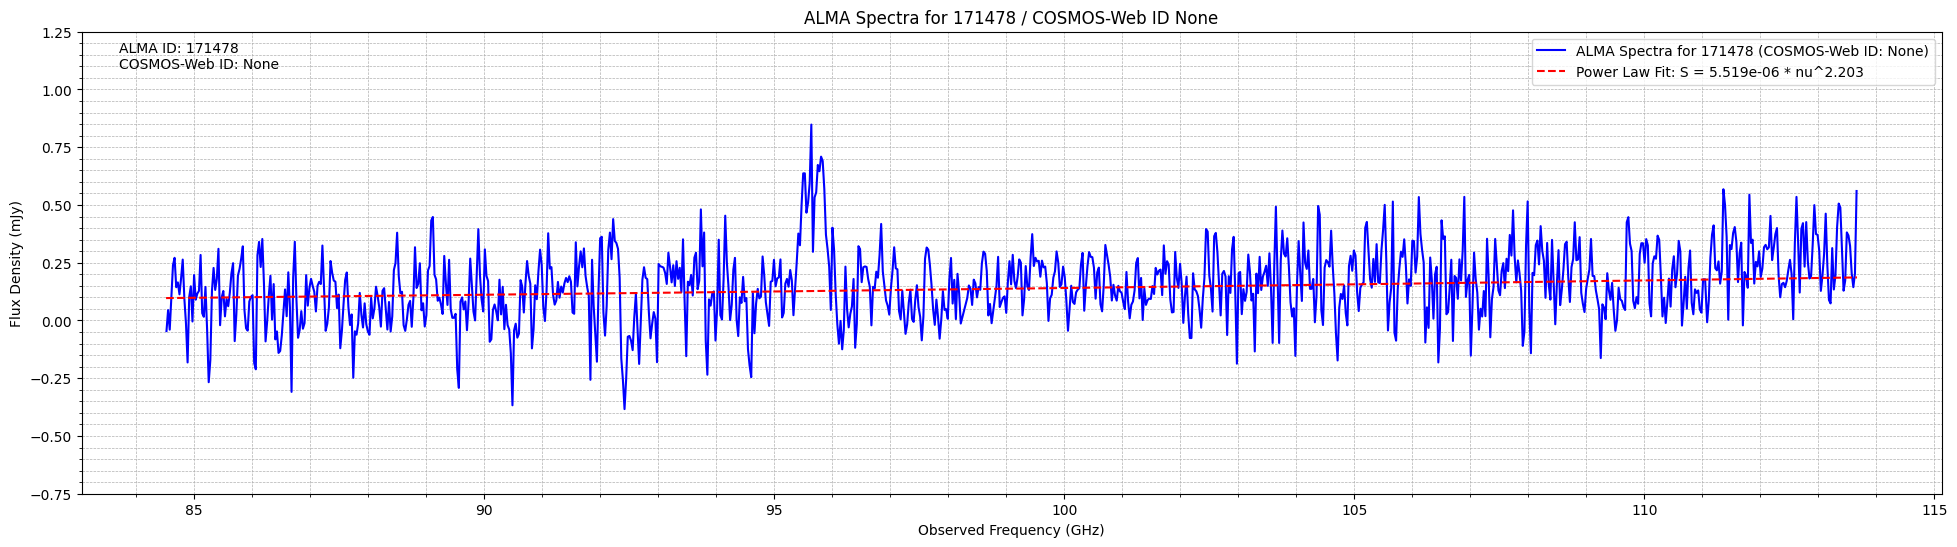

In [ ]:

def plot_alma_spectra(S2COSP0762_ALMA_SPECTRA_file = None, spectraData = None, ALMA_ID = None, COSMOS_WEB_ID = None, show_plot=True, bin_factor=2):
	#load S2COSP0762_ALMA_SPECTRA from txt (space separated) into numpy array, each row is freq, flux, flux_error
	if S2COSP0762_ALMA_SPECTRA_file is not None:
		s2cos0762_spectra = np.loadtxt(S2COSP0762_ALMA_SPECTRA_file)
	elif spectraData is not None:
		s2cos0762_spectra = spectraData
	else:
		raise ValueError("Either S2COSP0762_ALMA_SPECTRA_file or spectraData must be provided")

	s2cos0762_freq = s2cos0762_spectra[:, 0]  # in GHz
	s2cos0762_flux = s2cos0762_spectra[:, 1]  # in mJy
	s2cos0762_flux_error = s2cos0762_spectra[:, 2]  # in mJy


	#bin every 2 values in the spectra to reduce noise, by averaging the flux and flux_error values in each bin, and taking the mean of the frequency values in each bin as the new frequency value.
	bin_size = bin_factor
	n_bins = len(s2cos0762_freq) // bin_size
	s2cos0762_freq = s2cos0762_freq[:n_bins * bin_size]
	s2cos0762_flux = s2cos0762_flux[:n_bins * bin_size]
	s2cos0762_flux_error = s2cos0762_flux_error[:n_bins * bin_size]
	s2cos0762_freq_binned = np.mean(s2cos0762_freq.reshape(-1, bin_size), axis=1)
	s2cos0762_flux_binned = np.mean(s2cos0762_flux.reshape(-1, bin_size), axis=1)
	s2cos0762_flux_error_binned = np.mean(s2cos0762_flux_error.reshape(-1, bin_size), axis=1)

	#plot the spectra
	alma_spectra_fig, alma_spectra_ax = plt.subplots(figsize=(24, 6))
	alma_spectra_ax.plot(s2cos0762_freq_binned, s2cos0762_flux_binned, label=f'ALMA Spectra for {ALMA_ID} (COSMOS-Web ID: {COSMOS_WEB_ID})', color='blue')
	# alma_spectra_ax.fill_between(s2cos0762_freq_binned, s2cos0762_flux_binned - s2cos0762_flux_error_binned, s2cos0762_flux_binned + s2cos0762_flux_error_binned, color='blue', alpha=0.3, label='Flux Error')
	alma_spectra_ax.set_xlabel('Observed Frequency (GHz)')
	alma_spectra_ax.set_ylabel('Flux Density (mJy)')
	alma_spectra_ax.set_title(f'ALMA Spectra for {ALMA_ID} / COSMOS-Web ID {COSMOS_WEB_ID}')
	alma_spectra_ax.grid(True, which='both', linestyle='--', linewidth=0.5)
	alma_spectra_ax.minorticks_on()



	#try to find possible lines and mask out the lines from the spectra, by finding points where the flux is greater than 3 times the flux error, and masking those points out from the spectra before fitting the power law.
	signal_mask = s2cos0762_flux_binned > 3 * s2cos0762_flux_error_binned



	#include power law fit to the spectra, using np.polyfit on the log-log of the data, and plot the fit as a dashed line on the same plot. The power law is of the form S = A * nu^alpha, where S is the flux density, nu is the frequency, A is a normalization constant, and alpha is the spectral index. The fit should be done in log-log space, so we take the log of both frequency and flux density, and then use np.polyfit to fit a linear model to the log-log data. The slope of the fitted line will give us the spectral index alpha.
	#filter out any non-positive flux values before taking the log
	positive_flux_mask = s2cos0762_flux_binned > 0
	signal_mask = ~signal_mask & positive_flux_mask

	# Use the BUNDED (binned) arrays for masking/fit to avoid dimension mismatch
	if np.count_nonzero(signal_mask) > 1:
		log_freq = np.log10(s2cos0762_freq_binned[signal_mask])
		log_flux = np.log10(s2cos0762_flux_binned[signal_mask])
		#fit a linear model to the log-log data
		coeffs = np.polyfit(log_freq, log_flux, 1)
		alpha = coeffs[0]  # spectral index
		A = 10**coeffs[1]  # normalization constant
		#generate fitted flux values using the power law model evaluated on the original (unbinned) frequency grid for plotting
		fitted_flux = A * s2cos0762_freq**alpha
		#plot the fitted power law on the same plot as a dashed line
		alma_spectra_ax.plot(s2cos0762_freq, fitted_flux, label=f'Power Law Fit: S = {A:.3e} * nu^{alpha:.3f}', color='red', linestyle='--')
		alma_spectra_ax.legend()
	else:
		print("Not enough positive signal points in binned spectrum to perform power-law fit.")
		coeffs = np.array([np.nan, np.nan])
		alpha = np.nan
		A = np.nan
		fitted_flux = np.full_like(s2cos0762_freq, np.nan)

	#include in top left the ALMA ID and cosmos Web ID and z redshift
	z_redshift = np.inf
	alma_spectra_ax.text(0.02, 0.98, f'ALMA ID: {ALMA_ID}\nCOSMOS-Web ID: {COSMOS_WEB_ID}\n', transform=alma_spectra_ax.transAxes, verticalalignment='top')#, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

	alma_spectra_ax.set_ylim(bottom=-0.75, top=1.25)
	if show_plot:
		plt.show()
 
	return alma_spectra_fig, alma_spectra_ax, coeffs, alpha, A, fitted_flux, s2cos0762_freq, s2cos0762_flux, s2cos0762_flux_error, signal_mask, bin_size


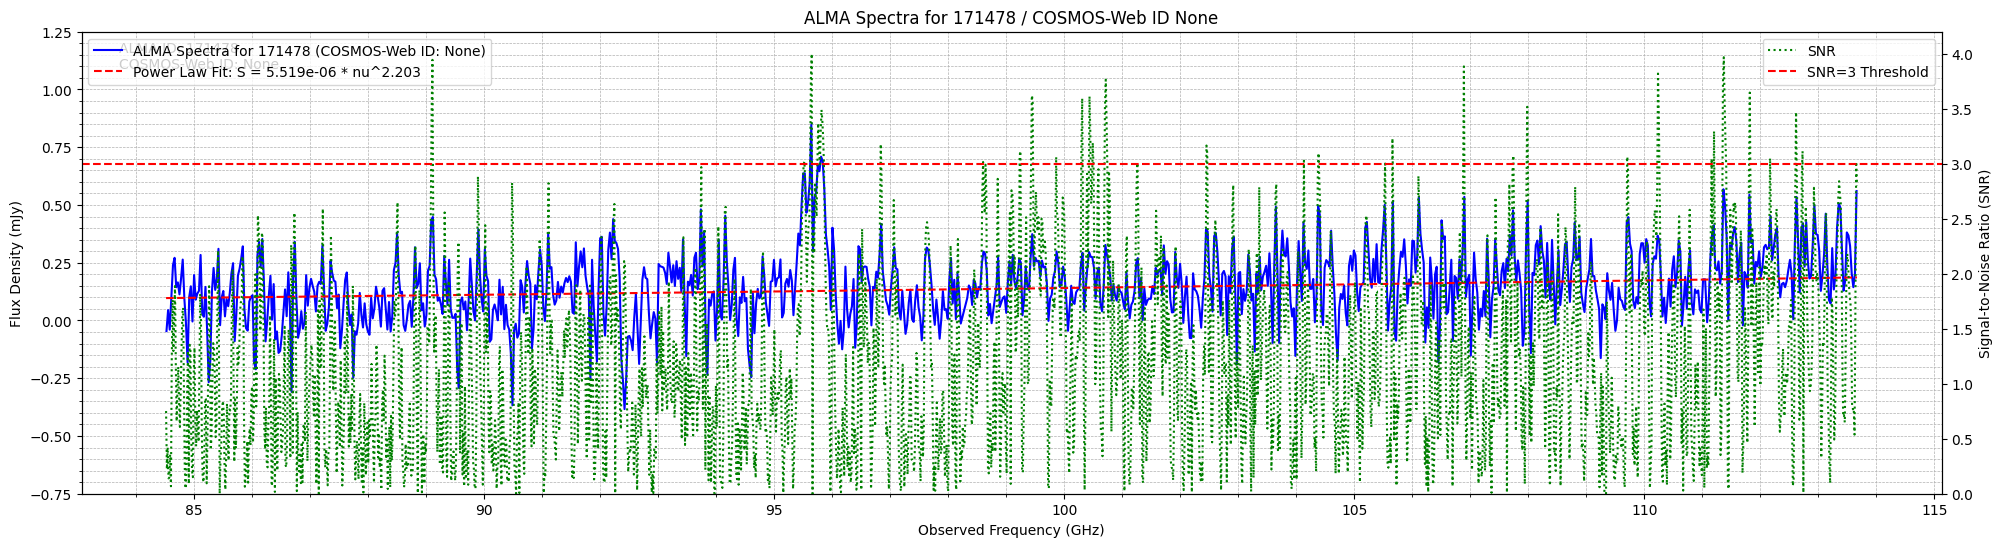

(<Figure size 2400x600 with 2 Axes>,
 <Axes: title={'center': 'ALMA Spectra for 171478 / COSMOS-Web ID None'}, xlabel='Observed Frequency (GHz)', ylabel='Flux Density (mJy)'>,
 <Axes: ylabel='Signal-to-Noise Ratio (SNR)'>)

In [ ]:
# plot the SNR for each frequency point in the spectra, as SNR = flux / flux_error, and plot it on a secondary y-axis on the same plot as the spectra, with a horizontal line at SNR=3 to indicate the detection threshold.
def plot_alma_spectra_with_snr(S2COSP0762_ALMA_SPECTRA, ALMA_ID, COSMOS_WEB_ID, show_plot=True):
    alma_spectra_fig, alma_spectra_ax, coeffs, alpha, A, fitted_flux, s2cos0762_freq, s2cos0762_flux, s2cos0762_flux_error, signal_mask, bin_size = plot_alma_spectra(S2COSP0762_ALMA_SPECTRA, ALMA_ID, COSMOS_WEB_ID, show_plot=False)
    
    # Calculate SNR
    snr = abs(s2cos0762_flux) / abs(s2cos0762_flux_error)
    
    # Create a secondary y-axis for SNR
    ax_snr = alma_spectra_ax.twinx()
    ax_snr.plot(s2cos0762_freq, snr, label='SNR', color='green', linestyle=':')
    ax_snr.axhline(y=3, color='red', linestyle='--', label='SNR=3 Threshold')
    ax_snr.set_ylabel('Signal-to-Noise Ratio (SNR)')
    ax_snr.set_ylim(bottom=0)
    
    # Add legends
    alma_spectra_ax.legend(loc='upper left')
    ax_snr.legend(loc='upper right')
    
    if show_plot:
        plt.show()
    
    return alma_spectra_fig, alma_spectra_ax, ax_snr

Fitted parameters: A1=0.4647950417077415, mu1=95.68503883365464, sigma1=0.16767324581622878, A2=286.94992069514, mu2=1e-10, sigma2=1e-10, C=0.19272393212905112
Estimated peak frequency of CO(5-4) line: 95.6850 GHz
Estimated redshift from CO(5-4) line: z = 5.0226


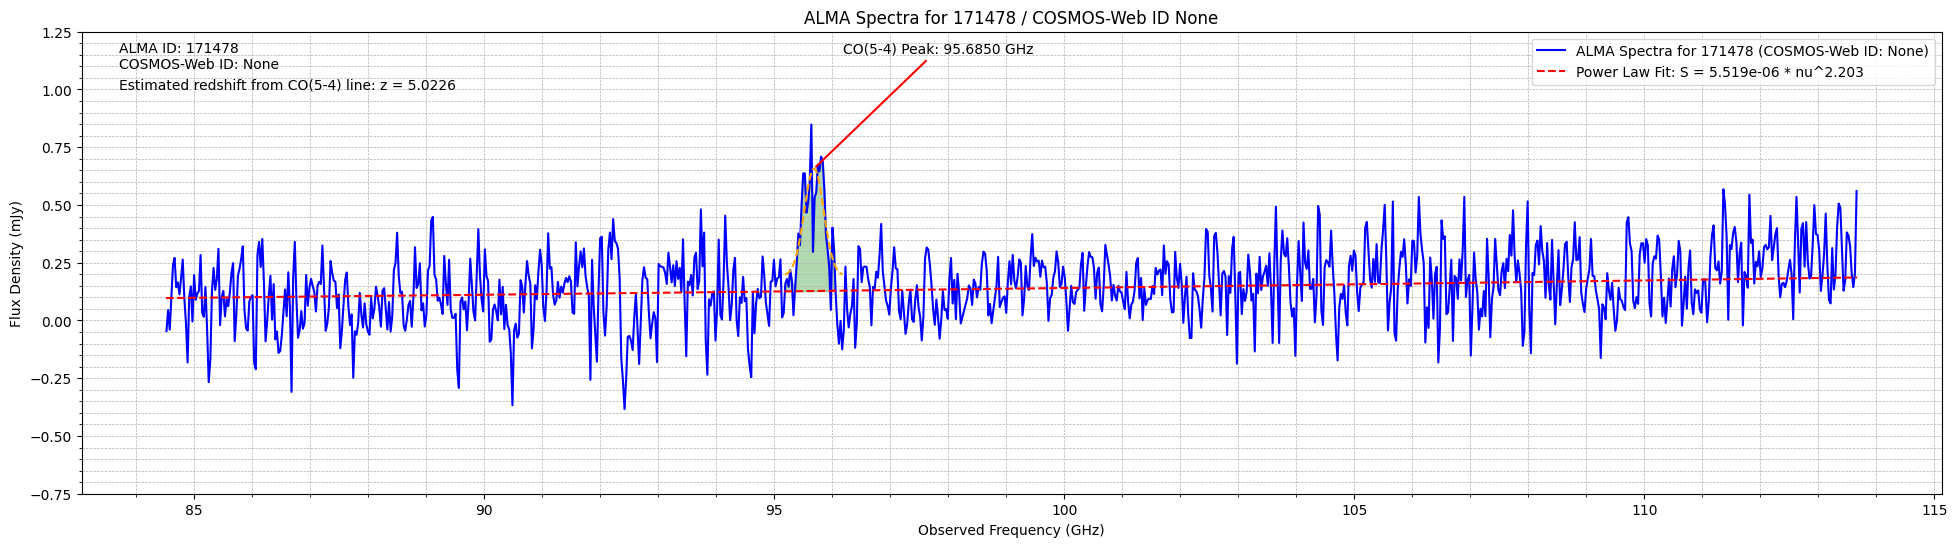

(<Figure size 2400x600 with 1 Axes>,
 <Axes: title={'center': 'ALMA Spectra for 171478 / COSMOS-Web ID None'}, xlabel='Observed Frequency (GHz)', ylabel='Flux Density (mJy)'>,
 5.022550725007526,
 95.68503883365464,
 0.16767324581622878,
 array([ 2.20285428, -5.25811018]),
 2.2028542818392305,
 5.519373912442416e-06,
 array([0.09697303, 0.09700842, 0.09704382, ..., 0.18616237, 0.1862129 ,
        0.18626343]),
 array([ 84.5156,  84.5296,  84.5436, ..., 113.636 , 113.65  , 113.664 ]),
 array([-0.128927 ,  0.0369203,  0.0675731, ...,  0.305299 ,  0.576542 ,
         0.544347 ]),
 array([0.171374, 0.164629, 0.160454, ..., 0.188515, 0.190846, 0.194143]),
 array([False,  True, False, ...,  True,  True,  True]),
 2)

In [ ]:
#try and find the redshift of the object from the ALMA spectra, by looking for the CO(5-4) line at rest frequency 576.268 GHz, and calculating the redshift as z = (rest_freq / obs_freq) - 1, where obs_freq is the observed frequency of the line in GHz. The CO(5-4) line should appear as a peak in the spectra, so we can try and fit a double Gaussian to the spectra to find the peak frequency. We can use scipy.optimize.curve_fit to fit a double Gaussian model to the spectra, and then find the peak frequency from the fitted parameters. The double Gaussian model is of the form:
# S(nu) = A1 * exp(-((nu - mu1)^2) / (2 * sigma1^2)) + A2 * exp(-((nu - mu2)^2) / (2 * sigma2^2)) + C
# where A1, A2 are the amplitudes of the two Gaussians, mu1, mu2 are the means (peak frequencies) of the two Gaussians, sigma1, sigma2 are the standard deviations of the two Gaussians, and C is a constant offset. We can use the fitted parameters to find the peak frequency of the CO(5-4) line, and then calculate the redshift as z = (rest_freq / obs_freq) - 1. We can also plot the fitted double Gaussian model on top of the spectra to visualize the fit.

def double_gaussian(nu, A1, mu1, sigma1, A2, mu2, sigma2, C):
    return (A1 * np.exp(-((nu - mu1) ** 2) / (2 * sigma1 ** 2)) +
            A2 * np.exp(-((nu - mu2) ** 2) / (2 * sigma2 ** 2)) + C)
    
# try to fit the double Gaussian model to the spectra using scipy.optimize.curve_fit, with initial guesses for the parameters based on the data. We can use the np.max and np.argmax functions to find the peak flux and its corresponding frequency, and use that as an initial guess for mu1. We can also use the standard deviation of the flux values as an initial guess for sigma1. For A1, we can use the peak flux value as an initial guess. For A2, mu2, sigma2, and C, we can use 0 as initial guesses. We can also set bounds for the parameters to ensure they are physically reasonable.
from scipy.optimize import curve_fit
from IPython.display import display

def plot_alma_spectra_with_co_fit(S2COSP0762_ALMA_SPECTRA_file = None, spectraData = None, ALMA_ID = None, COSMOS_WEB_ID = None, show_plot=True, bin_factor=2):
    co_fit_fig, co_fit_ax, coeffs, alpha, A, fitted_flux, s2cos0762_freq, s2cos0762_flux, s2cos0762_flux_error, signal_mask, bin_size = plot_alma_spectra(S2COSP0762_ALMA_SPECTRA_file=S2COSP0762_ALMA_SPECTRA_file, spectraData=spectraData, ALMA_ID=ALMA_ID, COSMOS_WEB_ID=COSMOS_WEB_ID, show_plot=False, bin_factor=bin_factor)

    positive_flux_mask = s2cos0762_flux > 0
    try:
        popt, pcov = curve_fit(double_gaussian, s2cos0762_freq[positive_flux_mask], s2cos0762_flux[positive_flux_mask],
                            p0=[np.max(s2cos0762_flux), s2cos0762_freq[np.argmax(s2cos0762_flux)], np.std(s2cos0762_flux), 0, 0, 0, 0],
                            bounds=([0, 0, 0, 0, 0, 0, -np.inf], [np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf]))
        A1_fit, mu1_fit, sigma1_fit, A2_fit, mu2_fit, sigma2_fit, C_fit = popt
        print(f"Fitted parameters: A1={A1_fit}, mu1={mu1_fit}, sigma1={sigma1_fit}, A2={A2_fit}, mu2={mu2_fit}, sigma2={sigma2_fit}, C={C_fit}")
        
        print(f"Estimated peak frequency of CO(5-4) line: {mu1_fit:.4f} GHz")
        # Calculate the redshift from the fitted peak frequency of the CO(5-4) line
        rest_freq_CO54 = 576.268  # GHz
        z_redshift = (rest_freq_CO54 / mu1_fit) - 1
        print(f"Estimated redshift from CO(5-4) line: z = {z_redshift:.4f}")
        # Plot the fitted double Gaussian model on top of the spectra to visualize the fit
        
        # fitted_flux_double_gaussian = double_gaussian(s2cos0762_freq, *popt)
        # co_fit_ax.plot(s2cos0762_freq, fitted_flux_double_gaussian, label='Fitted Double Gaussian', color='green', linestyle='--')
        #instead of plotting the fitted gaussian, plot a shaded region of the spectra above the power law fit, to show where the line is detected. Use the fitted mu1_fit and sigma1_fit to define the region of the line, and shade the region where the flux is above the power law fit.
        power_law_fit_flux = fitted_flux #A * s2cos0762_freq**alpha
        s2cos0762_freq_binned = np.mean(s2cos0762_freq.reshape(-1, bin_size), axis=1)
        s2cos0762_flux_binned = np.mean(s2cos0762_flux.reshape(-1, bin_size), axis=1)
        power_law_fit_flux_binned = np.mean(power_law_fit_flux.reshape(-1, bin_size), axis=1)
        line_region_mask = (s2cos0762_freq_binned > (mu1_fit - 3 * sigma1_fit)) & (s2cos0762_freq_binned < (mu1_fit + 3 * sigma1_fit)) & (s2cos0762_flux_binned > power_law_fit_flux_binned)
        co_fit_ax.fill_between(s2cos0762_freq_binned[line_region_mask], s2cos0762_flux_binned[line_region_mask], power_law_fit_flux_binned[line_region_mask], color='green', alpha=0.3, label='Detected CO(5-4) Line Region')
        
        #add the double gaussian fit to the plot
        near = np.abs(s2cos0762_freq - mu1_fit) < 3 * sigma1_fit
        co_fit_ax.plot(s2cos0762_freq[near], double_gaussian(s2cos0762_freq, *popt)[near], label='Fitted Double Gaussian', color='orange', linestyle='--')
        
        #add redshift text to the plot
        co_fit_ax.text(0.02, 0.90, f'Estimated redshift from CO(5-4) line: z = {z_redshift:.4f}', transform=co_fit_ax.transAxes, verticalalignment='top')#, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        #add annotation to the plot showing the fitted peak frequency of the CO(5-4) line
        co_fit_ax.annotate(f'CO(5-4) Peak: {mu1_fit:.4f} GHz', xy=(mu1_fit, double_gaussian(mu1_fit, *popt)), xytext=(mu1_fit + 0.5, double_gaussian(mu1_fit, *popt) + 0.5), arrowprops=dict(arrowstyle='-', color='red', lw=1.5), fontsize=10, color='black')
        
        if show_plot:
            plt.show()
        # try:
        #     co_fit_fig.canvas.draw_idle()
        # except Exception:
        #     pass
        # display(co_fit_fig)
    except Exception as e:
        print(f"Could not fit double Gaussian to the spectra: {e}")
        z_redshift = np.inf
        
    return co_fit_fig, co_fit_ax, z_redshift, mu1_fit, sigma1_fit, coeffs, alpha, A, fitted_flux, s2cos0762_freq, s2cos0762_flux, s2cos0762_flux_error, signal_mask, bin_size


Fitted parameters: A1=0.4647950417077415, mu1=95.68503883365464, sigma1=0.16767324581622878, A2=286.94992069514, mu2=1e-10, sigma2=1e-10, C=0.19272393212905112
Estimated peak frequency of CO(5-4) line: 95.6850 GHz
Estimated redshift from CO(5-4) line: z = 5.0226
z_CO = 5.0225  ->  expect H2O at 92.4751 GHz
Fitted H2O: emission A=4.118e-01 @ 92.2674 GHz (sig 0.0986); absorption A=-5.282e-01 @ 92.4034 GHz (sig 0.0588); C=4.891e-02
Systemic H2O frequency = 92.3423 GHz  ->  z = 5.0312
Emission-absorption velocity split = -441.7 km/s (P-Cygni signature)


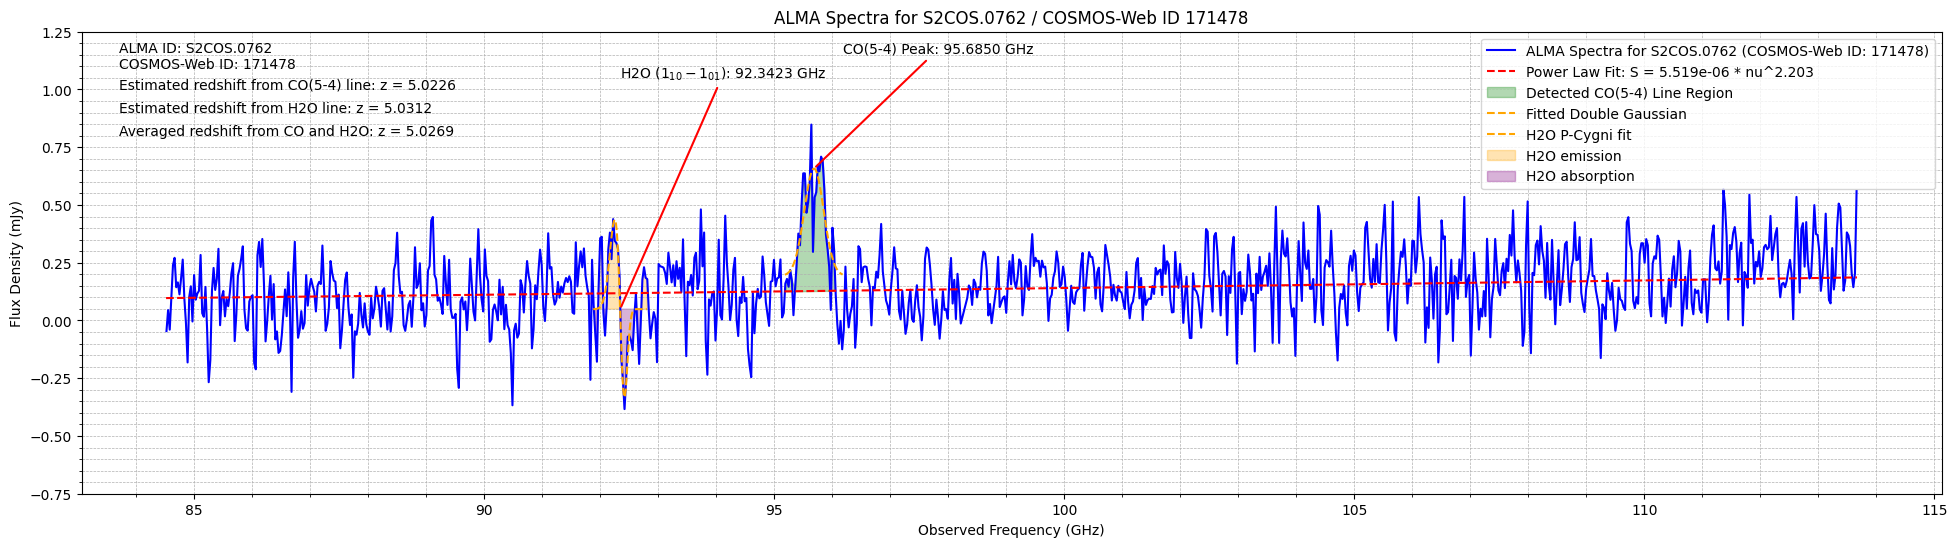

(<Figure size 2400x600 with 1 Axes>,
 <Axes: title={'center': 'ALMA Spectra for S2COS.0762 / COSMOS-Web ID 171478'}, xlabel='Observed Frequency (GHz)', ylabel='Flux Density (mJy)'>,
 5.031210352933954,
 92.34232722940462,
 0.07870238167246114,
 array([ 2.20285428, -5.25811018]),
 2.2028542818392305,
 5.519373912442416e-06,
 array([0.09697303, 0.09700842, 0.09704382, ..., 0.18616237, 0.1862129 ,
        0.18626343]),
 array([ 84.5156,  84.5296,  84.5436, ..., 113.636 , 113.65  , 113.664 ]),
 array([-0.128927 ,  0.0369203,  0.0675731, ...,  0.305299 ,  0.576542 ,
         0.544347 ]),
 array([0.171374, 0.164629, 0.160454, ..., 0.188515, 0.190846, 0.194143]),
 array([False,  True, False, ...,  True,  True,  True]),
 2)

In [ ]:
## Look for the H2O(1_{10}-1_{01}) line at rest 556.936 GHz. It is often a
## P-Cygni profile (emission on one side of systemic, absorption on the other),
## so we fit TWO Gaussians with opposite-sign amplitudes -- one emission
## (A>=0), one absorption (A<=0) -- and take the systemic (zero-crossing)
## frequency for the redshift.
rest_freq_H2O = 556.936  # GHz
rest_freq_CO54 = 576.2679305  # GHz, CO(5-4) rest

def plot_alma_spectra_with_h2o_fit(S2COSP0762_ALMA_SPECTRA_file = None, spectraData = None, ALMA_ID = None, COSMOS_WEB_ID = None, show_plot=True, bin_factor=2):
    h2o_co_fit_fig, h2o_co_fit_ax, co_z_redshift, mu1_fit, sigma1_fit, coeffs_h2o, alpha_h2o, A_h2o, fitted_flux_h2o, s2cos0762_freq, s2cos0762_flux, s2cos0762_flux_error, signal_mask_h2o, bin_size_h2o = plot_alma_spectra_with_co_fit(S2COSP0762_ALMA_SPECTRA_file, spectraData, ALMA_ID, COSMOS_WEB_ID, show_plot=False, bin_factor=bin_factor)

    # Initialise so the except/return path can never NameError.
    z_redshift_h2o = np.inf
    mu_h2o = sig_h2o = np.nan

    try:
        # Emission + absorption model: A_e >= 0, A_a <= 0 (enforced via bounds).
        def emit_abs(x, A_e, mu_e, sig_e, A_a, mu_a, sig_a, C):
            return (A_e * np.exp(-(x - mu_e)**2 / (2 * sig_e**2))
                  + A_a * np.exp(-(x - mu_a)**2 / (2 * sig_a**2)) + C)

        # Redshift from the CO fit -> where we expect H2O.
        z_CO = rest_freq_CO54 / mu1_fit - 1
        mu_H2O_expected = rest_freq_H2O / (1 + z_CO)
        print(f"z_CO = {z_CO:.4f}  ->  expect H2O at {mu_H2O_expected:.4f} GHz")

        # Window around the prediction; widen for a P-Cygni (both lobes must fit),
        # and exclude the CO core.
        half_win = 0.5  # GHz -- tune to cover emission AND absorption lobes
        win = (np.abs(s2cos0762_freq - mu_H2O_expected) < half_win) & \
            (np.abs(s2cos0762_freq - mu1_fit) > 6 * sigma1_fit)

        x, y = s2cos0762_freq[win], s2cos0762_flux[win]
        yerr = s2cos0762_flux_error[win]
        if len(x) < 8:
            raise RuntimeError(f"only {len(x)} channels in the H2O window; widen half_win or check masking")

        # Initial guesses: emission from the max, absorption from the min.
        C0 = np.median(y)
        imax, imin = np.argmax(y), np.argmin(y)
        p0 = [max(y.max() - C0, 1e-6), x[imax], sigma1_fit,
              min(y.min() - C0, -1e-6), x[imin], sigma1_fit, C0]
        bounds = ([0,      x.min(), 0,            -np.inf, x.min(), 0,            -np.inf],
                  [np.inf, x.max(), 5*sigma1_fit,  0,      x.max(), 5*sigma1_fit,  np.inf])

        popt_h2o, pcov_h2o = curve_fit(emit_abs, x, y, p0=p0, bounds=bounds,
                                       sigma=yerr, absolute_sigma=True)
        A_e, mu_e, sig_e, A_a, mu_a, sig_a, C_h2o = popt_h2o
        #  tighten sig_e/sig_a upper bounds or seed mu_e/mu_a from the expected blue/red offsets rather than from argmax/argmin

        # Systemic frequency = zero-crossing of (model - continuum) between the
        # two component centres; fall back to their midpoint if no crossing.
        lo, hi = sorted([mu_e, mu_a])
        xg = np.linspace(lo, hi, 1001)
        resid = emit_abs(xg, *popt_h2o) - C_h2o
        crossings = np.where(np.diff(np.sign(resid)))[0]
        mu_systemic = xg[crossings[0]] if crossings.size else 0.5 * (mu_e + mu_a)

        mu_h2o, sig_h2o = mu_systemic, 0.5 * (sig_e + sig_a)
        z_redshift_h2o = rest_freq_H2O / mu_systemic - 1
        c_kms = 299792.458
        dv = c_kms * (mu_e - mu_a) / mu_systemic  # emission-absorption velocity split

        print(f"Fitted H2O: emission A={A_e:.3e} @ {mu_e:.4f} GHz (sig {sig_e:.4f}); "
              f"absorption A={A_a:.3e} @ {mu_a:.4f} GHz (sig {sig_a:.4f}); C={C_h2o:.3e}")
        print(f"Systemic H2O frequency = {mu_systemic:.4f} GHz  ->  z = {z_redshift_h2o:.4f}")
        print(f"Emission-absorption velocity split = {dv:.1f} km/s (P-Cygni signature)")

        # Overplot the fitted profile and shade emission (above C) / absorption
        # (below C) relative to the fitted continuum.
        model_full = emit_abs(s2cos0762_freq, *popt_h2o)
        near = np.abs(s2cos0762_freq - mu_systemic) < 3 * (sig_e + sig_a)
        h2o_co_fit_ax.plot(s2cos0762_freq[near], model_full[near], color='orange',
                           ls='--', lw=1.5, label='H2O P-Cygni fit')
        # Shade emission / absorption on the SAME binned grid that is plotted,
        # so `where` matches the x/y length. C_h2o is the scalar fitted
        # continuum -- fill_between broadcasts it, so it must NOT be reshaped.
        nb_bins = len(s2cos0762_flux) // bin_factor
        freq_b = np.mean(s2cos0762_freq[:nb_bins * bin_factor].reshape(-1, bin_factor), axis=1)
        flux_b = np.mean(s2cos0762_flux[:nb_bins * bin_factor].reshape(-1, bin_factor), axis=1)

        near_b = np.abs(freq_b - mu_systemic) < 3 * (sig_e + sig_a)
        above = near_b & (flux_b > C_h2o)
        below = near_b & (flux_b < C_h2o)

        h2o_co_fit_ax.fill_between(freq_b, C_h2o, flux_b, where=above,
                                   color='orange', alpha=0.3, label='H2O emission')
        h2o_co_fit_ax.fill_between(freq_b, C_h2o, flux_b, where=below,
                                   color='purple', alpha=0.3, label='H2O absorption')

        h2o_co_fit_ax.annotate(f'H2O $(1_{{10}} - 1_{{01}})$: {mu_systemic:.4f} GHz',
                               xy=(mu_systemic, C_h2o),
                               xytext=(mu_systemic + 0.001, C_h2o + max(A_e, 1)),
                               arrowprops=dict(arrowstyle='-', color='red', lw=1.5),
                               fontsize=10, color='black')
        h2o_co_fit_ax.text(0.02, 0.85, f'Estimated redshift from H2O line: z = {z_redshift_h2o:.4f}',
                           transform=h2o_co_fit_ax.transAxes, verticalalignment='top')
        h2o_co_fit_ax.text(0.02, 0.80, f'Averaged redshift from CO and H2O: z = {(z_redshift_h2o + z_CO) / 2:.4f}',
                           transform=h2o_co_fit_ax.transAxes, verticalalignment='top')
        h2o_co_fit_ax.legend()
        if show_plot:
            plt.show()

    except Exception as e:
        print(f"Could not fit H2O P-Cygni profile to the spectra: {e}")
        z_redshift_h2o = np.inf

    return h2o_co_fit_fig, h2o_co_fit_ax, z_redshift_h2o, mu_h2o, sig_h2o, coeffs_h2o, alpha_h2o, A_h2o, fitted_flux_h2o, s2cos0762_freq, s2cos0762_flux, s2cos0762_flux_error, signal_mask_h2o, bin_size_h2o


In [ ]:
#  plot ALMA object S2COS.0762 aka COSMOS-Web ID 171478 specta, in the file each row is freq, flux, flux_error
# plot flux density (mJy) vs Observed frequency (GHz) as spectra line with shaded error region

ALMA_ID = 'S2COS.0762'
COSMOS_WEB_ID = 171478

alma_spectra_fig, alma_spectra_ax, coeffs, alpha, A, fitted_flux, s2cos0762_freq, s2cos0762_flux, s2cos0762_flux_error, signal_mask, bin_size = plot_alma_spectra(S2COSP0762_ALMA_SPECTRA, ALMA_ID, COSMOS_WEB_ID)
plot_alma_spectra_with_snr(S2COSP0762_ALMA_SPECTRA, ALMA_ID, COSMOS_WEB_ID)
plot_alma_spectra_with_co_fit(S2COSP0762_ALMA_SPECTRA, ALMA_ID, COSMOS_WEB_ID)
plot_alma_spectra_with_h2o_fit(S2COSP0762_ALMA_SPECTRA_file = S2COSP0762_ALMA_SPECTRA, ALMA_ID = ALMA_ID, COSMOS_WEB_ID = COSMOS_WEB_ID)

### download splatalogue

In [24]:
from astroquery.splatalogue import Splatalogue
from astropy.table import vstack

# Query lines by exact frequency range for CO and H2O
low_range = 300 * u.GHz
high_range = 900 * u.GHz
lines_co = Splatalogue.query_lines(min_frequency=low_range, max_frequency=high_range, chemical_name='Carbon Monoxide')
lines_h2o = Splatalogue.query_lines(min_frequency=low_range, max_frequency=high_range, chemical_name='Water')

lines = vstack([lines_co, lines_h2o], metadata_conflicts='silent')

# Export to an Astroquery table and write to a CSV file
lines.write('splatalogue_export_h2o_co.csv', format='csv', overwrite=True)


In [50]:
from utilities.fitLineSpectraModel import FitLineSpectraModel
from utilities.lineSpectraModelsEnum import LineSpectraModelsEnum

# H20_C0_SPLATALOGUE = '/Volumes/Apple SDXC Reader Media/dusty-red/splatalogue/2a027127-2ec3-4fc3-aea3-fbb2cb5241bc.csv'
H20_C0_SPLATALOGUE = 'splatalogue_export_h2o_co.csv'
fitLineSpectraModel = FitLineSpectraModel(line_spectra_model = LineSpectraModelsEnum.DoubleGaussian, list_molecule_lines_file=H20_C0_SPLATALOGUE)
s2cos0762_spectra = np.loadtxt(S2COSP0762_ALMA_SPECTRA)

In [67]:
results = fitLineSpectraModel.fit(s2cos0762_spectra, verbose=True, continuum_degree=1)

print("Fitted line spectra results:")
print(results)

Subtracted degree-1 continuum (coeffs [ 0.006 -0.405]).
Loaded [314.1195653 314.1196453 314.119653  ... 899.302169  899.8347023
 899.8460523] molecule lines from splatalogue_export_h2o_co.csv.
Median channel width is 1.400e-02 GHz; matching lines within +/-300 km/s (~1.00e-03 fractional).
Generated 217340 shared-redshift candidate line pairs.
  CO <font color="red">v = 3 + H<sub>2</sub>O <font color="red">v<sub>2</sub>, 2v<sub>2</sub>, v<sub>1</sub>, v<sub>3</sub></font> at z=3.6886 (score -1.000)
  13C18O+ + HDO at z=7.3905 (score -1.000)
  H<sub>2</sub>O <font color="red">v<sub>2</sub>, 2v<sub>2</sub>, v<sub>1</sub>, v<sub>3</sub></font> + <sup>13</sup>C<sup>17</sup>O at z=5.0213 (score -1.000)
  H<sub>2</sub>O <font color="red">v=0</font> + H<sub>2</sub>O <font color="red">v<sub>2</sub>, 2v<sub>2</sub>, v<sub>1</sub>, v<sub>3</sub></font> at z=3.8625 (score -1.000)
  CO<sup>+</sup> <font color="red">v = 1</font> + H<sub>2</sub>O <font color="red">v<sub>2</sub>, 2v<sub>2</sub>, v<sub

### download data from astroquery.alma instead of manually

In [103]:
import os, re, time
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord
from astroquery.alma import Alma

def _retry(fn, *a, tries=4, **k):
    for i in range(tries):
        try:
            return fn(*a, **k)
        except Exception as e:
            if i == tries - 1: raise
            time.sleep(2 ** i)              # archive resets connections; back off

def _is_line_cube(name):
    """True for a per-spw, pb-corrected line cube (not the combined continuum)."""
    n = name.lower().split('?')[0]
    return n.endswith('.pbcor.fits') and '.cube.' in n and '.cont.' not in n

def _dedup_key(name):
    """(MOUS uid, spw) parsed from the filename -- both are embedded in the name,
    so this needs no metadata columns. Collapses pbcor/image and repeat pipeline
    copies of the same spw within a MOUS; keeps distinct spws and distinct MOUS."""
    n = name.lower().split('?')[0]
    mous = re.search(r'uid___[\w]+', n)
    spw  = re.search(r'spw[\d_]+', n)
    return (mous.group(0) if mous else n, spw.group(0) if spw else '')

def download_alma_for_object(ra, dec, outdir, radius=30*u.arcsec,
                             bands=None, fmin_ghz=None, fmax_ghz=None,
                             max_gb=20):
    """Download per-spw pb-corrected line CUBES covering (ra, dec) into outdir.

    Only individual-spw line cubes are kept: the mfs-combined continuum images
    (`.cont.`) are excluded, and products are de-duplicated by (MOUS, spw) so
    pbcor/image copies and repeat pipeline products don't download twice.
    """
    alma = Alma()
    c = SkyCoord(ra, dec, unit='deg')
    obs = _retry(alma.query_region, c, radius=radius, public=True, science=True)
    if len(obs) == 0:
        print(f"no ALMA data at {ra},{dec}"); return None
    else:
        print(f"{len(obs)} obscore rows at {ra},{dec} "
              f"({len(set(str(x) for x in obs['member_ous_uid']))} observations)")

    # Narrow before downloading -- this is where you control cost.
    if bands:
        obs = obs[[str(b) in {str(x) for x in bands} for b in obs['band_list']]]
    if fmin_ghz is not None:
        obs = obs[obs['frequency'] >= fmin_ghz]
    if fmax_ghz is not None:
        obs = obs[obs['frequency'] <= fmax_ghz]
    if len(obs) == 0:
        print("nothing left after band/freq cut"); return None

    uids = sorted(set(str(x) for x in obs['member_ous_uid']))
    info = _retry(alma.get_data_info, uids, expand_tarfiles=True)

    names = [str(x) for x in info['access_url']]
    # 1) per-spw line cubes only (pbcor); drops raw/cal tars AND combined continuum.
    n_cont = sum(n.lower().split('?')[0].endswith('.pbcor.fits') and '.cont.' in n.lower()
                 for n in names)
    sel = info[[_is_line_cube(n) for n in names]]

    # 2) de-duplicate by (MOUS, spw) -> no repeated frequency ranges.
    seen, keep = set(), []
    for n in (str(x) for x in sel['access_url']):
        key = _dedup_key(n)
        keep.append(key not in seen)
        seen.add(key)
    sel = sel[keep]

    gb = np.nansum(np.array(sel['content_length'], float)) / 1e9
    print(f"{len(sel)} unique per-spw cubes (~{gb:.1f} GB); "
          f"skipped {n_cont} combined-continuum images")
    if len(sel) == 0:
        print("no per-spw line cubes found (only continuum?)"); return None
    if gb > max_gb:
        raise RuntimeError(f"{gb:.1f} GB exceeds max_gb={max_gb}; tighten filters")

    os.makedirs(outdir, exist_ok=True)
    return alma.download_files(list(sel['access_url']), savedir=outdir, cache=True)

In [ ]:
# if loop over all objects
# from utilities.almaSpectraHandler import AlmaSpectraHandler

# handlers = {}
# for obj_id, ra, dec in zip(cat['id'], cat['ra'], cat['dec']):
#     d = f'/Volumes/Apple SDXC Reader Media/dusty-red/data/alma-spectra/{obj_id}'
#     download_alma_for_object(ra, dec, d, bands=[3,6], max_gb=15)
#     if os.path.isdir(d) and any(f.endswith('.fits') for f in os.listdir(d)):
#         handlers[obj_id] = AlmaSpectraHandler(d)
#         spec = handlers[obj_id].get_alma_spectra(object_position=(ra, dec))


#just try obj 17338
obj_id = 17338
d = f'/Volumes/Sandisk/dusty-red/alma-spectra/{obj_id}'
RA, DEC = catalogHandler.get_obj_position(filtername = "condition_detection_reviewed", objectID=obj_id)
download_alma_for_object(ra=RA, dec=DEC, outdir=d, bands=[3,6], max_gb=15, radius = 0.1*u.arcsec)

20 obscore rows at 149.82683569809996,2.239004985418153 (5 observations)
20 unique per-spw cubes (~2.3 GB); skipped 390 combined-continuum images


['/Volumes/Apple SDXC Reader Media/dusty-red/data/alma-spectra/17338/member.uid___A001_X3645_Xd8.S21_100_sci.spw25.cube.I.pbcor.fits',
 '/Volumes/Apple SDXC Reader Media/dusty-red/data/alma-spectra/17338/member.uid___A001_X3645_Xd8.S21_100_sci.spw27.cube.I.pbcor.fits',
 '/Volumes/Apple SDXC Reader Media/dusty-red/data/alma-spectra/17338/member.uid___A001_X3645_Xd8.S21_100_sci.spw29.cube.I.pbcor.fits',
 '/Volumes/Apple SDXC Reader Media/dusty-red/data/alma-spectra/17338/member.uid___A001_X3645_Xd8.S21_100_sci.spw31.cube.I.pbcor.fits',
 '/Volumes/Apple SDXC Reader Media/dusty-red/data/alma-spectra/17338/member.uid___A001_X37b5_X187.lrd-100568_sci.spw11.cube.I.pbcor.fits',
 '/Volumes/Apple SDXC Reader Media/dusty-red/data/alma-spectra/17338/member.uid___A001_X37b5_X187.lrd-100568_sci.spw15.cube.I.pbcor.fits',
 '/Volumes/Apple SDXC Reader Media/dusty-red/data/alma-spectra/17338/member.uid___A001_X37b5_X187.lrd-100568_sci.spw18.cube.I.pbcor.fits',
 '/Volumes/Apple SDXC Reader Media/dusty-re

### load/generate alma spectra

In [65]:
# objectID = 17338
# objectID = 171478
#get object 2/29 
objectID = catalogHandler.get_ids(filtername = "condition_detection_reviewed")[8]
RA, DEC = catalogHandler.get_obj_position(filtername = "condition_detection_reviewed", objectID=objectID)
radius_sersic = catalogHandler.get_cat_photom('condition_detection_reviewed')[catalogHandler.get_cat_photom('condition_detection_reviewed')['id'] == objectID]['radius_sersic'][0]
# catalogHandler.get_cat_photom('condition_detection_reviewed')[catalogHandler.get_cat_photom('condition_detection_reviewed')['id'] == 171478][0]
print(f"Downloading ALMA data for object {objectID} at RA={RA}, DEC={DEC} with radius {radius_sersic * 3600 :.4f}...")
print(f"Checking ALMA spectra for object {objectID}...")

path_to_raw_spectra = f'/Volumes/Sandisk/dusty-red/alma-spectra/{objectID}'

almaSpectraHandler = AlmaSpectraHandler(path_to_raw_spectra)

Checking ALMA spectra for object 171478...
Filename: /Volumes/Sandisk/dusty-red/alma-spectra/171478/member.uid___A001_X133d_X25a9._S2COS.0762__sci.spw19.cube.I.pbcor.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     110   (800, 800, 116, 1)   float32   
 HDU Info: None
 Header Info: SIMPLE  =                    T /Standard FITS                                   BITPIX  =                  -32 /Floating point (32 bit)                         NAXIS   =                    4                                                  NAXIS1  =                  800                                                  NAXIS2  =                  800                                                  NAXIS3  =                  116                                                  NAXIS4  =                    1                                                  EXTEND  =                    T                                                  BSCALE  =   1.000000000

In [68]:
print(f"Available spectra files for object {objectID}:")
RA, DEC = catalogHandler.get_obj_position(filtername="condition_detection_reviewed", objectID=objectID)
almaSpectraData = almaSpectraHandler.get_alma_spectra(object_position=(RA, DEC), point_source=False, box_halfwidth_arcsec=radius_sersic * 3600)

# almaSpectraData = almaSpectraHandler.get_alma_spectra(box_halfwidth=-1, object_position=(RA, DEC), point_source=False, box_halfwidth_arcsec=radius_sersic * 3600)

Available spectra files for object 171478:
Box half-width converted from 0.49784287046785874 arcsec to 4 pixels.

Extracting spectrum from /Volumes/Sandisk/dusty-red/alma-spectra/171478/member.uid___A001_X133d_X25a9._S2COS.0762__sci.spw19.cube.I.pbcor.fits...


Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


  [timing] read data: 1.21s
Channel frequencies range: 93.055 - 94.852 GHz (116 channels)
  [timing] rms (116 chan): 0.00s

Extracting spectrum from /Volumes/Sandisk/dusty-red/alma-spectra/171478/member.uid___A001_X133d_X25b1._S2COS.0762__sci.spw23.cube.I.pbcor.fits...
  [timing] read data: 0.00s
Channel frequencies range: 111.852 - 113.680 GHz (118 channels)


Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


  [timing] rms (118 chan): 0.00s

Extracting spectrum from /Volumes/Sandisk/dusty-red/alma-spectra/171478/member.uid___A001_X133d_X25a1._S2COS.0762__sci.spw19.cube.I.pbcor.fits...
  [timing] read data: 0.00s
Channel frequencies range: 86.227 - 88.055 GHz (118 channels)


...

  [timing] rms (118 chan): 0.00s

Extracting spectrum from /Volumes/Sandisk/dusty-red/alma-spectra/171478/S2COS0762-CO54-clean.fits...
  [timing] read data: 0.00s
Channel frequencies range: 95.647 - 95.647 GHz (1 channels)
  [timing] rms (1 chan): 0.00s

Extracting spectrum from /Volumes/Sandisk/dusty-red/alma-spectra/171478/member.uid___A001_X133d_X25ad._S2COS.0762__sci.spw21.cube.I.pbcor.fits...
  [timing] read data: 0.00s
Channel frequencies range: 106.742 - 108.570 GHz (118 channels)


Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


  [timing] rms (118 chan): 0.00s

Extracting spectrum from /Volumes/Sandisk/dusty-red/alma-spectra/171478/member.uid___A001_X133d_X25a9._S2COS.0762__sci.spw21.cube.I.pbcor.fits...
  [timing] read data: 0.00s
Channel frequencies range: 103.352 - 105.148 GHz (116 channels)


Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


  [timing] rms (116 chan): 0.02s


In [49]:
# View all spw cubes together in CARTA -- do NOT combine them into one FITS.
#
# The spws sit on different spatial grids (different imsize per execution) and
# are non-contiguous in frequency, so concatenating them into a single cube
# would require regridding and would still need a fake linear spectral axis.
# CARTA handles this natively: open every cube and let it match them using each
# file's real WCS.
#
#   File > Open Image  (select all cubes, or point CARTA at the folder below)
#   Image > Matching > enable Spatial and Spectral
#
# The list below is sorted by starting frequency for convenience.

almadir = f'/Volumes/Sandisk/dusty-red/alma-spectra/{objectID}'


def _channel0_freq(hdr):
    """World frequency (header units) at channel 0, for sorting."""
    crval3 = hdr.get('CRVAL3', hdr.get('CRVAL'))
    cdelt3 = hdr.get('CDELT3', hdr.get('CDELT'))
    crpix3 = hdr.get('CRPIX3', hdr.get('CRPIX', 1))
    if crval3 is None:
        return float('inf')
    if cdelt3 is None:
        return float(crval3)
    return float(crval3 + (1 - crpix3) * cdelt3)


infos = []  # (channel0_freq_ghz, path, shape)
for file in almaSpectraHandler.get_all_fit_files_loaded():
    hdr = fits.getheader(file)                       # header only -- no pixel read
    data_shape = tuple(hdr[f'NAXIS{i}'] for i in range(hdr['NAXIS'], 0, -1))
    infos.append((_channel0_freq(hdr) / 1e9, file, data_shape))

infos.sort(key=lambda e: e[0])

print(f"{len(infos)} cubes for object {objectID} (sorted by start frequency):")
print(f"Open these in CARTA from: {almadir}\n")
for f0, file, shape in infos:
    f0_str = f"{f0:8.3f} GHz" if f0 != float('inf') else "    n/a    "
    print(f"  {f0_str}  shape={shape!s:>18}  {os.path.basename(file)}")


18 cubes for object 171478 (sorted by start frequency):
Open these in CARTA from: /Volumes/Sandisk/dusty-red/alma-spectra/171478

     0.000 GHz  shape=     (1, 200, 200)  S2COS0762-CO54-clean.fits
    84.523 GHz  shape=(1, 118, 960, 960)  member.uid___A001_X133d_X25a1._S2COS.0762__sci.spw17.cube.I.pbcor.fits
    86.227 GHz  shape=(1, 118, 960, 960)  member.uid___A001_X133d_X25a1._S2COS.0762__sci.spw19.cube.I.pbcor.fits
    87.930 GHz  shape=(1, 118, 900, 900)  member.uid___A001_X133d_X25a5._S2COS.0762__sci.spw17.cube.I.pbcor.fits
    89.633 GHz  shape=(1, 118, 900, 900)  member.uid___A001_X133d_X25a5._S2COS.0762__sci.spw19.cube.I.pbcor.fits
    91.352 GHz  shape=(1, 116, 800, 800)  member.uid___A001_X133d_X25a9._S2COS.0762__sci.spw17.cube.I.pbcor.fits
    93.055 GHz  shape=(1, 116, 800, 800)  member.uid___A001_X133d_X25a9._S2COS.0762__sci.spw19.cube.I.pbcor.fits
    94.742 GHz  shape=(1, 118, 960, 960)  member.uid___A001_X133d_X25ad._S2COS.0762__sci.spw17.cube.I.pbcor.fits
    96.523 

In [69]:
# print almaSpectraData as a pandas dataframe with columns: 'frequency', 'flux', 'flux_error'
# almaSpectraData is an astropy.table.Table; convert to pandas safely
almaSpectraData_df = almaSpectraData.to_pandas()
expected_cols = ['frequency', 'flux', 'flux_error']
if all(c in almaSpectraData_df.columns for c in expected_cols):
	almaSpectraData_df = almaSpectraData_df[expected_cols]
else:
	print("Available columns:", list(almaSpectraData_df.columns))
print(almaSpectraData_df)

Available columns: ['file', 'channel', 'frequency_ghz', 'flux_mjy', 'flux_err_mjy']
                                                   file  channel  \
0     /Volumes/Sandisk/dusty-red/alma-spectra/171478...        0   
1     /Volumes/Sandisk/dusty-red/alma-spectra/171478...        1   
2     /Volumes/Sandisk/dusty-red/alma-spectra/171478...        2   
3     /Volumes/Sandisk/dusty-red/alma-spectra/171478...        3   
4     /Volumes/Sandisk/dusty-red/alma-spectra/171478...        4   
...                                                 ...      ...   
1994  /Volumes/Sandisk/dusty-red/alma-spectra/171478...      113   
1995  /Volumes/Sandisk/dusty-red/alma-spectra/171478...      114   
1996  /Volumes/Sandisk/dusty-red/alma-spectra/171478...      115   
1997  /Volumes/Sandisk/dusty-red/alma-spectra/171478...      116   
1998  /Volumes/Sandisk/dusty-red/alma-spectra/171478...      117   

      frequency_ghz  flux_mjy  flux_err_mjy  
0         84.523498 -0.022238      0.097077  
1      

Fitted parameters: A1=0.40854004024872215, mu1=95.73363190123828, sigma1=0.0931831691857285, A2=0.004659409145030784, mu2=1e-10, sigma2=1e-10, C=0.08624647356684804
Estimated peak frequency of CO(5-4) line: 95.7336 GHz
Estimated redshift from CO(5-4) line: z = 5.0195
z_CO = 5.0195  ->  expect H2O at 92.5221 GHz
Fitted H2O: emission A=2.775e-01 @ 92.2596 GHz (sig 0.0501); absorption A=-1.716e-01 @ 92.4502 GHz (sig 0.1009); C=-9.594e-03
Systemic H2O frequency = 92.3349 GHz  ->  z = 5.0317
Emission-absorption velocity split = -618.9 km/s (P-Cygni signature)


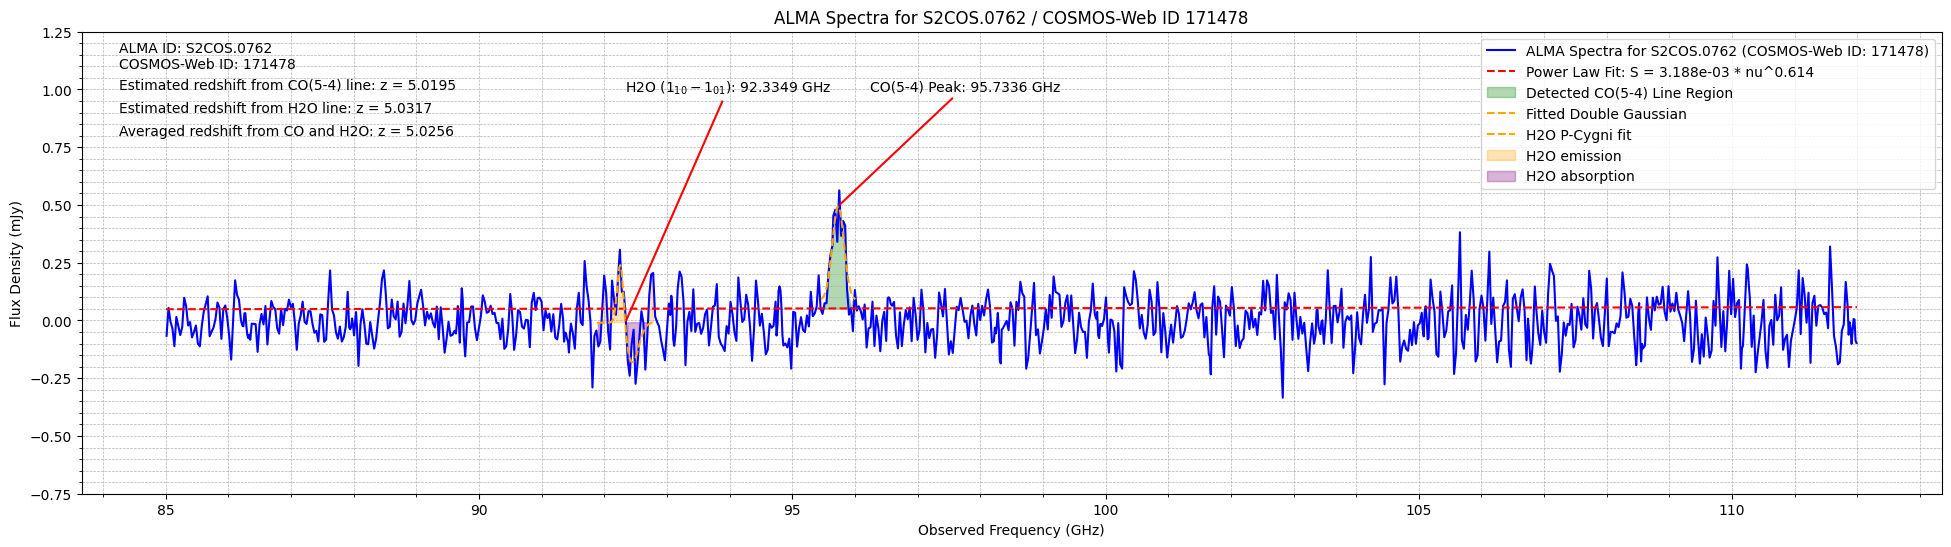

(<Figure size 2400x600 with 1 Axes>,
 <Axes: title={'center': 'ALMA Spectra for S2COS.0762 / COSMOS-Web ID 171478'}, xlabel='Observed Frequency (GHz)', ylabel='Flux Density (mJy)'>,
 5.031696426094527,
 92.33488568664777,
 0.07550091913446741,
 array([ 0.61351035, -2.49644795]),
 0.6135103526126932,
 0.003188247652038812,
 array([0.04867379, 0.04867928, 0.04868476, ..., 0.05763853, 0.05763861,
        0.05764347]),
 array([ 85.00785053,  85.02347482,  85.03909911, ..., 111.97663019,
        111.97687456, 111.9922572 ]),
 array([-0.09128241, -0.04168179,  0.07459202, ..., -0.06413977,
        -0.0802825 , -0.11458608]),
 array([0.08610985, 0.09742555, 0.0985174 , ..., 0.13989431, 0.1520502 ,
        0.15912525]),
 array([False,  True, False, False, False,  True, False, False, False,
         True,  True, False, False, False, False, False, False, False,
        False,  True,  True,  True, False, False, False,  True,  True,
         True, False,  True,  True,  True, False, False,  True,  

In [75]:
# try plotting the spectra using the plot_alma_spectra_with_h2o_fit function
fullDataTable = almaSpectraData_df.to_numpy()
#only keep the 2,3,4 columns (frequency, flux, flux_error)
fullDataTable = fullDataTable[:, 0:3]
# Extract only the numeric columns: frequency, flux, flux_error
fullDataTable = almaSpectraData_df[['frequency_ghz', 'flux_mjy', 'flux_err_mjy']].to_numpy()
#trim the data to only include rows where frequency is between 85 and 112 GHz
fullDataTable = fullDataTable[(fullDataTable[:, 0] >= 85) & (fullDataTable[:, 0] <= 112)]
plot_alma_spectra_with_h2o_fit(spectraData = fullDataTable, ALMA_ID = ALMA_ID, COSMOS_WEB_ID = COSMOS_WEB_ID, bin_factor=2)

### continuum

In [6]:
# load the S2COSP0762_ALMA_CLEAN fits file and read columns of the data, and plot the image with WCS coordinates, and overlay the position of the object in the condition_detection_reviewed catalog, using the RA and Dec of the object to convert to pixel coordinates in the ALMA image using the WCS information in the ALMA fits header.

s2cos0762_alma_fits = fits.open(S2COSP0762_ALMA_CLEAN)
print(f"S2COSP0762 ALMA fits groups: {s2cos0762_alma_fits.info()}")
s2cos0762_alma_image = s2cos0762_alma_fits[0].data
s2cos0762_alma_header = s2cos0762_alma_fits[0].header
print(f"S2COSP0762 ALMA header keys: {s2cos0762_alma_header}")
s2cos0762_alma_wcs = WCS(s2cos0762_alma_header)
print(f"S2COSP0762 ALMA WCS info: {s2cos0762_alma_wcs}") 

print(f"S2COSP0762 ALMA image shape: {s2cos0762_alma_image.shape}")



Filename: /Volumes/Apple SDXC Reader Media/dusty-red/data/alma-spectra/S2COS0762-CO54-clean.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      44   (200, 200, 1)   float32   


S2COSP0762 ALMA fits groups: None
S2COSP0762 ALMA header keys: SIMPLE  =                    T         /                                        BITPIX  =                  -32         /                                        NAXIS   =                    3         /                                        NAXIS1  =                  200         /                                        NAXIS2  =                  200         /                                        NAXIS3  =                    1         /                                        DATAMIN = -0.1444304216420E-03         /                                        DATAMAX =  0.3859859425575E-03         /                                        BUNIT   = 'Jy/beam     '               /                                        CTYPE1  = 'RA---ARC    '               /                                        CRVAL1  =  0.1503750000000E+03         /                                        CDELT1  = -0.2777777948778E-04         /                 

In [94]:
import matplotlib
print(matplotlib.__version__)

3.10.9


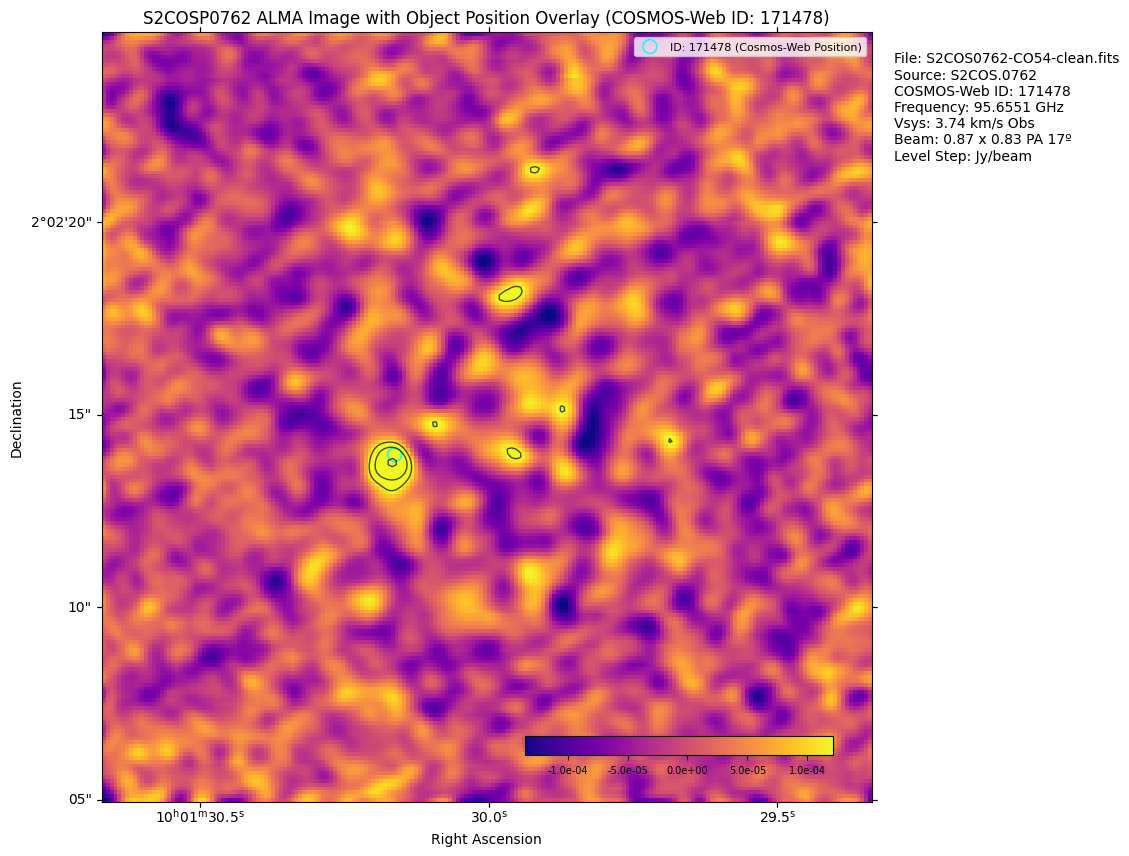

In [21]:
from astropy.visualization import ZScaleInterval
# plot the ALMA image with WCS coordinates, and overlay the position of the object in the condition_detection_reviewed catalog.
# Use the celestial (2D) WCS and a 2D image slice to avoid the "more than 2 pixel dimensions" ValueError.
alma_img_2d = np.squeeze(s2cos0762_alma_image)  # remove singleton spectral axis if present
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': s2cos0762_alma_wcs.celestial})
interval = ZScaleInterval()
vmin, vmax = interval.get_limits(alma_img_2d)
ax.imshow(alma_img_2d, origin='lower', cmap='plasma', vmin=vmin, vmax=vmax,)

#draw contour lines at 3, 5, 10, 20 sigma above the background noise level, where the background noise level is estimated as the standard deviation of the pixel values in a region of the image that does not contain any sources.

#set background_noise_level to be the standard devation of the image after we mask out 3 sigma pixels above the first estimate of the background noise level
background_noise_level = np.std(alma_img_2d)
mask = alma_img_2d < 3 * background_noise_level
background_noise_level = np.std(alma_img_2d[mask])
contour_levels = [3 * background_noise_level, 5 * background_noise_level, 9 * background_noise_level, 11 * background_noise_level]
ax.contour(alma_img_2d, levels=contour_levels, colors='black', linewidths=1, alpha=0.7)

obj = next((o for o in catalogHandler.get_cat_photom('condition_detection_reviewed') if o['id'] == COSMOS_WEB_ID), None)
if obj is not None:
    ra, dec = obj['ra'], obj['dec']
    # plot marker in world coordinates (RA, Dec) so the WCSAxes places it correctly
    ax.scatter(ra, dec, transform=ax.get_transform('world'),
               s=100, edgecolor='cyan', facecolor='none',
               label=f"ID: {obj['id']} (Cosmos-Web Position)")
    ax.legend(loc='upper right', fontsize=8)
    
    ax.set_xlabel('Right Ascension')
    ax.set_ylabel('Declination')
    
    #include colorbar for the image intensity values
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    import matplotlib.axes as maxes
    from matplotlib.ticker import FuncFormatter
    divider = make_axes_locatable(ax)
    # cax = divider.append_axes("right", size="5%", pad=0.1)
    # cax = divider.append_axes("right", size="5%", pad=0.1, axes_class=maxes.Axes)  # <- key
    # cbar = plt.colorbar(ax.images[0], cax=cax,#None,#cax,
    #                 format=FuncFormatter(lambda x, _: f"{x:.1e}"))
    # [x0, y0, width, height] in axes fractions (0–1). Bottom-right, small.
    cax = ax.inset_axes([0.55, 0.06, 0.4, 0.025])
    cbar = plt.colorbar(ax.images[0], cax=cax, orientation='horizontal',
                        format=FuncFormatter(lambda x, _: f"{x:.1e}"))
    cbar.ax.tick_params(labelsize=7)          # small tick labels

#include data info on right side of the plot including info about file, source, header information like frequency, vsys, beam, level step, and any other relevant information from the header. Use a text box to display this information in a readable format.
filename = str(S2COSP0762_ALMA_CLEAN).split('/')[-1]
#convert beam from degrees to arcsec
beam_maj_arcsec = s2cos0762_alma_header.get('BMAJ', 'N/A') * 3600 if s2cos0762_alma_header.get('BMAJ', 'N/A') != 'N/A' else 'N/A'
beam_min_arcsec = s2cos0762_alma_header.get('BMIN', 'N/A') * 3600 if s2cos0762_alma_header.get('BMIN', 'N/A') != 'N/A' else 'N/A'
#beam PA in degrees
beam_pa_deg = s2cos0762_alma_header.get('BPA', 'N/A') if s2cos0762_alma_header.get('BPA', 'N/A') != 'N/A' else 'N/A'
frequency = s2cos0762_alma_header.get('ALTRVAL', 'N/A') if s2cos0762_alma_header.get('ALTRVAL', 'N/A') != 'N/A' else 'N/A'
#convert frequency to GHz
frequency_ghz = frequency / 1e9 if frequency != 'N/A' else 'N/A'

header_info = f"File: {filename}\nSource: {ALMA_ID}\nCOSMOS-Web ID: {COSMOS_WEB_ID}\nFrequency: {frequency_ghz:.4f} GHz\nVsys: {s2cos0762_alma_header.get('VELO-OBS', 'N/A')/1e3:.2f} km/s Obs\nBeam: {beam_maj_arcsec:.2f} x {beam_min_arcsec:.2f} PA {beam_pa_deg:.2g}º\nLevel Step: {s2cos0762_alma_header.get('BUNIT', 'N/A')}\n"
props = dict(boxstyle='round', facecolor='white', alpha=0.8)

fig = ax.figure
# cbar_pos = cax.get_position()
# fig.text(
#     cbar_pos.x1 + 0.02,
#     cbar_pos.y0 + cbar_pos.height - 0.1,#/ 2,
#     header_info,
#     transform=fig.transFigure,
#     fontsize=10,
#     va='center',
#     ha='left',
#     # bbox=props,
# )
#instead put header_info in the top on the right side of the plot in the whitespace
plot_pos = ax.get_position()
fig.text(
    plot_pos.x1 + 0.02,
    plot_pos.y0 + plot_pos.height - 0.02,
    header_info,
    transform=fig.transFigure,
    fontsize=10,
    va='top',
    ha='left',
    # bbox=props,
)

ax.set_title(f"S2COSP0762 ALMA Image with Object Position Overlay (COSMOS-Web ID: {COSMOS_WEB_ID})")
plt.show()

# SED Fit

In [30]:
# create a table which consolidates the flux measurements from JWST and radio (VLA 3Ghz, CHAMPS, ALMA, Superdeblended)
#will eventually CIGALE SED fit

# CIGALE naming conventions: 
# File containing the input data. The columns are:
# * 'id': name of the object.
# * 'redshift': redshift of the object. If 0, the distance is assumed to
# be 10 pc. If negative the photometric mode is enabled. In that case an
# explicit redshift grid must be provided in the redshfting module.
# * 'distance' (Mpc, optional): distance in Mpc. Optional, if present it
# will be used in lieu of the distance computed from the redshift
# assuming a Planck et al. (2018) cosmology.
# * band fluxes: fluxes in filters in mJy. Each column is identified
# with a unique filter name, for instance jwst.nircam.F200W for the 2 μm
# filter of the NIRCAM instrument onboard JWST. The known filters are
# avalaible from the command 'pcigale-filters list'.
# * line fluxes: fluxes in lines in W/m². Each column is identified
# after a unique line name prefixed with 'line.', for instance
# line.H-alpha. The known filters are available from the command
# 'pcigale-filters list'. It is possible to combine lines together, for
# instance line.NII-654.8+H-alpha+NII-658.3 will be the sum of Hα and
# the adjacent NII lines.
# * physical properties: values of the intensive and extensive physical
# properties (e.g., dust.luminosity for the dust luminosity). To
# determine the format of the columns and the units, it is suggested to
# do a minimal run and examine the output FITS table.
# * uncertainties: the uncertainties for the band and line fluxes as
# well as for the physical properties are given using the same column
# names with the '_err' suffix.
# Important notes:
# * Fluxes can be positive or negative.
# * Upper limits are indicated with a negative value for the
# uncertainty.
# * In case some fluxes are missing for some objects, they can be
# replaced with NaN.
# * This file is optional to generate the configuration file, in
# particular for the savefluxes module.
super_table = Table(
    names=('id', 'redshift', 'RA', 'DEC',
           'jwst.nircam.F115W', 'jwst.nircam.F115W_err',
           'jwst.nircam.F150W', 'jwst.nircam.F150W_err',
           'jwst.nircam.F277W', 'jwst.nircam.F277W_err',
           'jwst.nircam.F444W', 'jwst.nircam.F444W_err',
           'jwst.miri.F770W',   'jwst.miri.F770W_err',
           # custom-registered filters:
           'vla.S',      'vla.S_err',
           'alma.A3Band3', 'alma.A3Band3_err',
           'alma.champs',     'alma.champs_err'),
    dtype=('i4', 'f8', 'f8', 'f8',
           'f4','f4', 'f4','f4', 'f4','f4', 'f4','f4', 'f4','f4',
           'f4','f4', 'f4','f4', 'f4', 'f4'),
    meta={'name': 'Super Table of Flux Measurements from JWST and Radio'},
)

DUSTY_RED_GALAXY_ID = 171478


# for i, obj in enumerate(catalogHandler.get_cat_photom('condition_detection_reviewed')[catalogHandler.get_cat_photom('condition_detection_reviewed')['id'] == DUSTY_RED_GALAXY_ID]):
for i, obj in enumerate(catalogHandler.get_cat_photom('condition_detection_reviewed')):
       
       obj_id = obj['id']
       ra, dec = obj['ra'], obj['dec']
       redshift = catalogHandler.get_z_redshift('condition_detection_reviewed')[catalogHandler.get_cat_photom('condition_detection_reviewed')['id'] == obj_id][0]
       #JWST fluxes in mJy, with errors
       # print(catalogHandler.get_filter_flux_of_id(obj_id, 'condition_detection_reviewed', 'f115w'))
       f115, f115_err = catalogHandler.get_filter_flux_of_id(obj_id, 'condition_detection_reviewed', 'f115w')[0], catalogHandler.get_filter_flux_of_id(obj_id, 'condition_detection_reviewed', 'f115w')[1]
       f150, f150_err = catalogHandler.get_filter_flux_of_id(obj_id, 'condition_detection_reviewed', 'f150w')[0], catalogHandler.get_filter_flux_of_id(obj_id, 'condition_detection_reviewed', 'f150w')[1]
       f277, f277_err = catalogHandler.get_filter_flux_of_id(obj_id, 'condition_detection_reviewed', 'f277w')[0], catalogHandler.get_filter_flux_of_id(obj_id, 'condition_detection_reviewed', 'f277w')[1]
       f444w, f444w_err = catalogHandler.get_filter_flux_of_id(obj_id, 'condition_detection_reviewed', 'f444w')[0], catalogHandler.get_filter_flux_of_id(obj_id, 'condition_detection_reviewed', 'f444w')[1]
       f770w, f770w_err = catalogHandler.get_filter_flux_of_id(obj_id, 'condition_detection_reviewed', 'f770w')[0], catalogHandler.get_filter_flux_of_id(obj_id, 'condition_detection_reviewed', 'f770w')[1]
       
       #dict stores the object id as key, and a tuple of (ok_detection, intensity_point, intensity_avg, intensity_peak, stdev_value, rms_value) as value
       # VLA 3Ghz data is in Jy/Beam
       if matched_vla.get(obj_id) is not None and matched_vla[obj_id][0]:
              vla_flux, vla_flux_err = matched_vla[obj_id][3] * 1000, matched_vla[obj_id][4] * 1000
       else:
              vla_flux, vla_flux_err = matched_vla[obj_id][3] * 1000, matched_vla[obj_id][4] * -1000
       
       # champs data is in Jy/Beam
       if matched_champs_image.get(obj_id) is not None and matched_champs_image[obj_id][0]:
              # print(matched_champs_image[obj_id])
              champs_flux, champs_flux_err = matched_champs_image[obj_id][3] * 1000, matched_champs_image[obj_id][4] * 1000
       else:
              champs_flux, champs_flux_err = matched_champs_image[obj_id][3] * 1000, matched_champs_image[obj_id][4] * -1000
       
       # ALMA A3 data is in mJy/Beam
       if matched_almaA3_prior.get(obj_id) is not None and matched_almaA3_prior[obj_id][0]:
              print(f"Matched ALMA A3 prior for object {obj_id}: ")#{matched_almaA3_prior[obj_id]}")
              # matched_almaA3_prior[obj_id] is an astropy.table.Row; convert to a Table (or dict) before printing
              print(Table([matched_almaA3_prior[obj_id]]).to_pandas())
              almaA3_flux, almaA3_flux_err = matched_almaA3_prior[obj_id]['Total_flux_pbcor'], matched_almaA3_prior[obj_id]['E_Total_flux_pbcor'] * 1
              print(f"Observed ALMA A3 frequency for object {obj_id}: {micron_wavelength_to_frequency(matched_almaA3_prior[obj_id]['Obs_wavelength']) / 1e9:.4f} GHz")
       else:
              print(f"No matched ALMA A3 prior for object {obj_id}. Setting flux and error to NaN.")
              almaA3_flux, almaA3_flux_err = np.nan, np.nan #matched_almaA3_prior[obj_id]['Total_flux_pbcor'], matched_almaA3_prior[obj_id]['E_Total_flux_pbcor'] * -1
              
       # Band 3	~100 GHz	alma.band3
       # Band 4	~145 GHz	alma.band4
       # Band 6	~230 GHz (1.2 mm)	alma.band6
       # Band 7	~345 GHz (870 µm)	alma.band7
       # Band 8	~460 GHz	alma.band8
       
       # show the table of flux measurements for the object
       
       # if confident in jwst redshift, use redshift.
       # otherwise if have a redshift from the CO(5-4) line, use that.
       # else use -1 for the redshift.
       if obj_id == DUSTY_RED_GALAXY_ID:
              redshift = 5.025
       super_table.add_row((obj_id, redshift, ra, dec,
                            f115, f115_err,
                            f150, f150_err,
                            f277, f277_err,
                            f444w, f444w_err,
                            f770w, f770w_err,
                            vla_flux, vla_flux_err,
                            almaA3_flux, almaA3_flux_err,
                            champs_flux, champs_flux_err))
       
# display(HTML(f"""
# <div style="max-height:400px; overflow-y:auto; overflow-x:auto;">
#        {super_table.to_pandas().to_html(index=False)}
# </div>
# """))

#print as pd.dataframe
# import pandas as pd
super_table_df = super_table.to_pandas()
super_table_df

No matched ALMA A3 prior for object 17338. Setting flux and error to NaN.
No matched ALMA A3 prior for object 26910. Setting flux and error to NaN.
No matched ALMA A3 prior for object 56404. Setting flux and error to NaN.
No matched ALMA A3 prior for object 79810. Setting flux and error to NaN.
No matched ALMA A3 prior for object 92586. Setting flux and error to NaN.
No matched ALMA A3 prior for object 96066. Setting flux and error to NaN.
No matched ALMA A3 prior for object 136802. Setting flux and error to NaN.
No matched ALMA A3 prior for object 167591. Setting flux and error to NaN.
Matched ALMA A3 prior for object 171478: 
       ID          RA       Dec  Total_flux_pbcor  E_Total_flux_pbcor  \
0  836111  150.375749  2.037208          0.208701            0.017842   

   E_Total_flux_sim_pbcor     Pbcor  Pb_corr_pb_image Pb_corr_equation  \
0                0.018985  0.996939           1.00307          1.01138   

   Peak_flux  ... RMS_noise Maj_beam  Min_beam    PA_beam  \
0    0.

,id,redshift,RA,DEC,jwst.nircam.F115W,jwst.nircam.F115W_err,jwst.nircam.F150W,jwst.nircam.F150W_err,jwst.nircam.F277W,jwst.nircam.F277W_err,jwst.nircam.F444W,jwst.nircam.F444W_err,jwst.miri.F770W,jwst.miri.F770W_err,vla.S,vla.S_err,alma.A3Band3,alma.A3Band3_err,alma.champs,alma.champs_err
0,17338,7.6443,149.826836,2.239005,0.019538,0.015395,0.016947,0.013228,0.019641,0.007522,0.200522,0.008002,0.234295,0.026098,0.005741,-0.002094,NaN,NaN,0.292051,-0.134332
1,26910,8.2474,149.820874,2.307251,0.008473,0.026613,0.028440,0.021983,0.013382,0.008614,0.126624,0.010433,0.150074,0.026410,0.006751,-0.002276,NaN,NaN,0.335302,0.107277
2,56404,8.3892,149.909220,2.211260,-0.009704,0.014585,0.030096,0.012613,0.015090,0.006754,0.100762,0.008169,0.136101,0.026878,0.006706,0.002189,NaN,NaN,0.335110,-0.115009
3,79810,0.3027,150.039343,2.051379,0.048863,0.024238,0.026785,0.021151,0.016909,0.006976,0.044479,0.007796,0.115912,0.018110,0.005540,-0.002387,NaN,NaN,0.233936,-0.128795
4,92586,8.4820,150.063441,2.135579,-0.006697,0.024585,0.020319,0.021388,0.017227,0.011647,0.172413,0.012507,0.272436,0.026670,0.004683,-0.002219,NaN,NaN,0.222181,-0.096433
5,96066,7.6599,150.102117,2.143862,-0.011250,0.010723,0.007467,0.012755,0.011661,0.004602,0.073281,0.007649,0.155325,0.025565,0.003925,-0.002418,NaN,NaN,0.304775,-0.147248
6,136802,8.5453,150.305498,2.070558,0.005641,0.014968,0.007822,0.013080,0.018942,0.006696,0.200532,0.007553,0.337360,0.025526,0.008026,0.002276,NaN,NaN,0.169619,-0.084636
7,167591,7.9337,150.390583,1.995666,-0.001257,0.025470,0.037868,0.020950,0.021821,0.008364,0.160773,0.010104,0.215292,0.025624,0.003940,-0.002324,NaN,NaN,0.241931,-0.103643
8,171478,5.0250,150.375679,2.037211,-0.016620,0.015385,-0.007610,0.013331,0.020761,0.006936,0.172480,0.008308,0.988363,0.018645,0.009425,0.002216,0.208701,0.017842,2.894677,0.125498
9,183201,6.4746,150.346119,1.989711,0.007782,0.013386,-0.004181,0.011253,0.012640,0.005995,0.072167,0.007315,0.189134,0.026218,0.006077,-0.002109,NaN,NaN,1.006776,0.178002


In [31]:
#save the table to a fits file
super_table.write('cigale-run/super_table_flux_measurements.fits', overwrite=True)

In [ ]:
#run cigale-run/run_cigale.py

In [77]:
#get the cigale run's posteriors into a table
CIGALE_RUN_DIR = 'cigale-run/out'
CIGALE_RESULTS_FILE = os.path.join(CIGALE_RUN_DIR, 'results.fits')
cigale_results = Table.read(CIGALE_RESULTS_FILE)

#dont include columns which start with 'bayes.'
cigale_results_no_bayes = cigale_results#[[c for c in cigale_results.colnames if not c.startswith('bayes.')]]

row = cigale_results_no_bayes.to_pandas().iloc[0]

params = sorted({c[:-4] if c.endswith('_err') else c for c in row.index})
summary = pd.DataFrame({
    'value': [row.get(p) for p in params],
    'err':   [row.get(f'{p}_err') for p in params],
}, index=params)

with pd.option_context('display.max_rows', None, 'display.float_format', '{:.4g}'.format):
    display(summary)


,value,err
bayes.agn.accretion_power,0,0
bayes.agn.fracAGN,0,0
bayes.agn.luminosity,0,0
bayes.alma.A3Band6,3.234,0.151
bayes.alma.champs,2.613,0.1221
bayes.attenuation.Av_BC,4976,7515
bayes.attenuation.Av_ISM,1.791,0.1081
bayes.dust.luminosity,5.904e+39,2.952e+38
bayes.jwst.miri.F770W,0.6323,0.02996
bayes.jwst.nircam.F115W,7.994e-10,4.501e-09


In [41]:
#for all of the condition_detection_reviewed, print in the following format:
# Object 1/29 : ID 17338 , RA, DEC
for i, obj in enumerate(catalogHandler.get_cat_photom('condition_detection_reviewed')):
    obj_id = obj['id']
    ra, dec = obj['ra'], obj['dec']
    print(f"Object {i+1}/{len(catalogHandler.get_cat_photom('condition_detection_reviewed'))} : ID {obj_id} , RA, DEC {ra:.6f} {dec:.6f}")

Object 1/29 : ID 17338 , RA, DEC 149.826836 2.239005
Object 2/29 : ID 26910 , RA, DEC 149.820874 2.307251
Object 3/29 : ID 56404 , RA, DEC 149.909220 2.211260
Object 4/29 : ID 79810 , RA, DEC 150.039343 2.051379
Object 5/29 : ID 92586 , RA, DEC 150.063441 2.135579
Object 6/29 : ID 96066 , RA, DEC 150.102117 2.143862
Object 7/29 : ID 136802 , RA, DEC 150.305498 2.070558
Object 8/29 : ID 167591 , RA, DEC 150.390583 1.995666
Object 9/29 : ID 171478 , RA, DEC 150.375679 2.037211
Object 10/29 : ID 183201 , RA, DEC 150.346119 1.989711
Object 11/29 : ID 184688 , RA, DEC 150.304084 2.050700
Object 12/29 : ID 291236 , RA, DEC 150.038611 1.990003
Object 13/29 : ID 333050 , RA, DEC 150.202186 1.948589
Object 14/29 : ID 334444 , RA, DEC 150.148610 1.978487
Object 15/29 : ID 369896 , RA, DEC 150.342839 1.893590
Object 16/29 : ID 384271 , RA, DEC 150.290523 1.937188
Object 17/29 : ID 385251 , RA, DEC 149.950560 2.484330
Object 18/29 : ID 413568 , RA, DEC 149.894142 2.514836
Object 19/29 : ID 488601 